In [1]:
import pandas as pd

# 导入Excel文件
df_rent_train = pd.read_excel('ruc_Class25Q2_test_rent.xlsx')

# 查看数据基本信息（可选）
print("数据形状（行数, 列数）：", df_rent_train.shape)
print("\n前5行数据：")
print(df_rent_train.head())
print("\n列名列表：")
print(df_rent_train.columns.tolist())  # 查看所有列名，确认是否包含需要的特征

数据形状（行数, 列数）： (9773, 46)

前5行数据：
        ID  城市      户型   装修       楼层       面积   朝向       交易时间 付款方式 租赁方式  ...  \
0  2000000   1  2室2厅1卫  精装修  低楼层/18层   86.94㎡  南 北 2025-08-01  NaN   整租  ...   
1  2000001  10  2室1厅1卫  精装修   低楼层/8层   72.60㎡    南 2025-05-23  月付价   整租  ...   
2  2000002   3  2室2厅1卫  精装修  中楼层/20层   98.00㎡    南 2025-02-18  NaN   整租  ...   
3  2000003   0  2室1厅1卫  精装修  高楼层/12层   98.97㎡  东 西 2025-02-17  季付价   整租  ...   
4  2000004   3  3室2厅2卫  精装修  中楼层/23层  170.53㎡    南 2025-03-24  季付价   整租  ...   

      供水        供暖     供电       燃气费    供热费     停车位  停车费用     coord_x  \
0     民水       自采暖     民电  2.15元/m³    NaN  1600.0   100  117.345687   
1     民水       NaN     民电  3.45元/m³    NaN   200.0   800  114.279469   
2    NaN       NaN    NaN       NaN    NaN     NaN   NaN  121.684578   
3  商水/民水  集中供暖/自采暖  商电/民电  2.61元/m³  30元/㎡  2317.0  1200  117.323901   
4    NaN       NaN    NaN       NaN    NaN     NaN   NaN  121.718296   

     coord_y                       客户反馈  
0  40.44723

In [2]:
import pandas as pd
import re

def score_house_type(house_type):
    """根据户型字符串计算得分（总分10分）"""
    score = 0
    # 1. 室数量评分（4分）
    room_match = re.search(r'(\d+)室|(\d+)房间|(\d+)居室', str(house_type))
    if '未知室' in str(house_type) or '车库' in str(house_type):
        room_score = 0
    elif room_match:
        room_score = 4
    else:
        room_score = 0  # 无室信息（如纯“车库”）
    score += room_score
    
    # 2. 厅数量评分（3分）
    hall_match = re.search(r'(\d+)厅', str(house_type))
    if '未知室' in str(house_type) and not hall_match:
        hall_score = 0
    elif hall_match:
        hall_score = 3
    else:
        hall_score = 1  # 有室信息但无厅信息（如9房间、10居室）
    score += hall_score
    
    # 3. 卫数量评分（3分）
    bath_match = re.search(r'(\d+)卫', str(house_type))
    if '未知室' in str(house_type) and not bath_match:
        bath_score = 0
    elif bath_match:
        bath_score = 3
    else:
        bath_score = 1  # 有室/厅信息但无卫信息（如8室0厅、5室4厅）
    score += bath_score
    
    return score

# 应用打分函数到df_rent_train的“户型”列
df_rent_train['户型完整度评分'] = df_rent_train['户型'].apply(score_house_type)

# 查看评分结果分布
print("户型完整度评分分布：")
print(df_rent_train['户型完整度评分'].value_counts().sort_index())
print("\n前10条数据的户型与评分：")
print(df_rent_train[['户型', '户型完整度评分']].head(10))

户型完整度评分分布：
户型完整度评分
6       12
8      129
10    9632
Name: count, dtype: int64

前10条数据的户型与评分：
       户型  户型完整度评分
0  2室2厅1卫       10
1  2室1厅1卫       10
2  2室2厅1卫       10
3  2室1厅1卫       10
4  3室2厅2卫       10
5  3室2厅1卫       10
6  3室2厅2卫       10
7  3室1厅1卫       10
8  2室1厅1卫       10
9  1室1厅1卫       10


In [3]:
import pandas as pd

# 检查“户型”列的空缺值数量
missing_count = df_rent_train['户型'].isnull().sum()
print(f"户型列的空缺值数量：{missing_count}")

# 若存在空缺值，删除包含空缺值的行
if missing_count > 0:
    df_rent_train_clean = df_rent_train.dropna(subset=['户型']).copy()
    print(f"已删除含空缺值的行，处理后数据量：{df_rent_train_clean.shape[0]} 行（原数据：{df_rent_train.shape[0]} 行）")
else:
    df_rent_train_clean = df_rent_train.copy()
    print("户型列无空缺值，无需删除")

# 确认处理结果（可选）
print("\n处理后户型列的空缺值检查：", df_rent_train_clean['户型'].isnull().sum())

df_rent_train=df_rent_train_clean

户型列的空缺值数量：0
户型列无空缺值，无需删除

处理后户型列的空缺值检查： 0


In [4]:
import pandas as pd

# 1. 查看原始“装修”列的部分数据（可选，用于确认处理前状态）
print("处理前的部分数据：")
print(df_rent_train['装修'].head(10))

# 2. 填充空缺值为0
df_rent_train['装修'] = df_rent_train['装修'].fillna(0)

# 3. 将“精装修”转换为1（其他非NaN值保持原样，若有需要可进一步处理）
df_rent_train['装修'] = df_rent_train['装修'].apply(lambda x: 1 if x == '精装修' else x)

# 4. 确认处理结果
print("\n处理后的部分数据：")
print(df_rent_train['装修'].head(10))

# 5. 检查空缺值是否已填充
print("\n处理后空缺值数量：", df_rent_train['装修'].isnull().sum())

处理前的部分数据：
0    精装修
1    精装修
2    精装修
3    精装修
4    精装修
5    精装修
6    NaN
7    精装修
8    NaN
9    精装修
Name: 装修, dtype: object

处理后的部分数据：
0    1
1    1
2    1
3    1
4    1
5    1
6    0
7    1
8    0
9    1
Name: 装修, dtype: int64

处理后空缺值数量： 0


In [5]:
import pandas as pd
import re

def score_floor(floor):
    """对“楼层”列的单个值进行打分"""
    score = 0
    # 1. 信息完整性评分（4分）
    if re.match(r'\d+/\d+层', str(floor)):  # 明确“当前层/总层数”
        info_score = 4
    elif re.match(r'(\d+层|地下\d+层|地下室/\d+层)', str(floor)):  # 仅当前层或总层数
        info_score = 2
    else:  # 模糊描述（低楼层、车库等）
        info_score = 0
    score += info_score
    
    # 2. 数值合理性评分（3分）
    if re.match(r'\d+/\d+层', str(floor)):
        current, total = map(int, re.findall(r'\d+', str(floor))[:2])
        if current > 0 and total > 0 and current <= total:
            value_score = 3
        else:
            value_score = 1
    elif re.match(r'地下\d+层|地下室/\d+层', str(floor)):
        value_score = 1  # 地下层数值合理但非正整数
    elif re.match(r'\d+层', str(floor)):
        current = int(re.findall(r'\d+', str(floor))[0])
        if current > 0:
            value_score = 1  # 仅当前层，总层数未知
        else:
            value_score = 0
    else:
        value_score = 0  # 无层数数值
    score += value_score
    
    # 3. 业务可分析性评分（3分）
    if re.match(r'\d+/\d+层', str(floor)):
        analytic_score = 3
    elif re.match(r'(\d+层|地下\d+层|地下室/\d+层)', str(floor)):
        analytic_score = 1
    else:
        analytic_score = 0
    score += analytic_score
    
    return score

# 应用打分函数到“楼层”列
df_rent_train['楼层完整度评分'] = df_rent_train['楼层'].apply(score_floor)

# 查看评分结果分布
print("楼层完整度评分分布：")
print(df_rent_train['楼层完整度评分'].value_counts().sort_index())
print("\n前10条数据的楼层与评分：")
print(df_rent_train[['楼层', '楼层完整度评分']].head(10))

楼层完整度评分分布：
楼层完整度评分
0     8289
4       40
10    1444
Name: count, dtype: int64

前10条数据的楼层与评分：
        楼层  楼层完整度评分
0  低楼层/18层        0
1   低楼层/8层        0
2  中楼层/20层        0
3  高楼层/12层        0
4  中楼层/23层        0
5   30/45层       10
6  中楼层/34层        0
7   中楼层/6层        0
8  高楼层/32层        0
9   中楼层/9层        0


In [6]:
import pandas as pd

# 1. 检查“楼层完整度评分”列的空缺值数量
missing_score_count = df_rent_train['楼层完整度评分'].isnull().sum()
print(f"楼层完整度评分列的空缺值数量：{missing_score_count}")

# 2. 若存在空缺值，删除包含空缺值的行；无空缺值则直接保留原数据
if missing_score_count > 0:
    # 复制数据避免修改原表，仅删除目标列有缺失的行
    df_rent_train_clean = df_rent_train.dropna(subset=['楼层完整度评分']).copy()
    print(f"处理后数据量：{df_rent_train_clean.shape[0]} 行（原数据：{df_rent_train.shape[0]} 行）")
    print(f"已删除 {missing_score_count} 条含缺失值的记录")
else:
    df_rent_train_clean = df_rent_train.copy()
    print("楼层完整度评分列无空缺值，无需删除")

# 3. 验证处理结果（确认无残留缺失值）
final_missing_count = df_rent_train_clean['楼层完整度评分'].isnull().sum()
print(f"\n最终验证：楼层完整度评分列空缺值数量 = {final_missing_count}")

df_rent_train=df_rent_train_clean

楼层完整度评分列的空缺值数量：0
楼层完整度评分列无空缺值，无需删除

最终验证：楼层完整度评分列空缺值数量 = 0


In [7]:
import pandas as pd
import re

# 查看处理前的部分数据（可选）
print("处理前的面积列部分数据：")
print(df_rent_train['面积'].head(10))

# 提取数字（支持整数、小数，忽略单位）
df_rent_train['面积_数值'] = df_rent_train['面积'].apply(
    lambda x: float(re.findall(r'(\d+\.?\d*)', str(x))[0]) if re.findall(r'(\d+\.?\d*)', str(x)) else None
)

# 查看处理结果
print("\n处理后的面积数值部分数据：")
print(df_rent_train[['面积', '面积_数值']].head(10))

# 检查是否有提取失败的记录（结果为None的情况）
failed_count = df_rent_train['面积_数值'].isnull().sum()
print(f"\n提取失败的记录数：{failed_count}（可手动检查这些记录的格式）")

处理前的面积列部分数据：
0     86.94㎡
1     72.60㎡
2     98.00㎡
3     98.97㎡
4    170.53㎡
5     86.77㎡
6    135.00㎡
7     52.09㎡
8    106.50㎡
9     63.00㎡
Name: 面积, dtype: object

处理后的面积数值部分数据：
        面积   面积_数值
0   86.94㎡   86.94
1   72.60㎡   72.60
2   98.00㎡   98.00
3   98.97㎡   98.97
4  170.53㎡  170.53
5   86.77㎡   86.77
6  135.00㎡  135.00
7   52.09㎡   52.09
8  106.50㎡  106.50
9   63.00㎡   63.00

提取失败的记录数：0（可手动检查这些记录的格式）


In [8]:
import pandas as pd

def score_orientation(orientation):
    """对单个朝向数据进行打分（总分10分）"""
    # 处理空值或非字符串格式
    if pd.isna(orientation) or not isinstance(orientation, str):
        return 0
    
    # 拆分朝向列表（按空格分割）
    orient_list = [o.strip() for o in orientation.split()]
    core_orts = ["东", "南", "东南", "西南"]  # 核心朝向
    key_orts = ["南", "东南"]  # 关键加分朝向
    
    # 1. 计算基础分：核心朝向数量（5分）
    core_count = len([o for o in orient_list if o in core_orts])
    if core_count >= 3:
        base_score = 5
    elif core_count == 2:
        base_score = 3
    elif core_count == 1:
        base_score = 1
    else:
        base_score = 0
    
    # 2. 计算加分项：关键朝向权重（5分）
    has_south = "南" in orient_list
    has_southeast = "东南" in orient_list
    has_east_southwest = "东" in orient_list or "西南" in orient_list
    
    if has_south and has_southeast:
        add_score = 5
    elif has_south or has_southeast:
        add_score = 3
    elif has_east_southwest:
        add_score = 1
    else:
        add_score = 0
    
    # 3. 特殊情况：直接计0分
    if "未知" in orient_list or (core_count == 0 and len(orient_list) == 1 and "北" in orient_list):
        total_score = 0
    else:
        total_score = base_score + add_score
    
    return total_score

# 应用打分函数到“朝向”列
df_rent_train['朝向评分'] = df_rent_train['朝向'].apply(score_orientation)

# 查看评分结果
print("朝向评分分布：")
print(df_rent_train['朝向评分'].value_counts().sort_index())
print("\n前10条数据的朝向与评分：")
print(df_rent_train[['朝向', '朝向评分']].head(10))

朝向评分分布：
朝向评分
0     1173
2     1027
4     7370
6      125
8       69
10       9
Name: count, dtype: int64

前10条数据的朝向与评分：
    朝向  朝向评分
0  南 北     4
1    南     4
2    南     4
3  东 西     2
4    南     4
5    南     4
6  南 北     4
7    南     4
8    南     4
9    南     4


In [9]:
import pandas as pd

# 1. 检查“朝向评分”列的空缺值数量
missing_orient_score = df_rent_train['朝向评分'].isnull().sum()
print(f"朝向评分列的空缺值数量：{missing_orient_score}")

# 2. 若存在空缺值，删除包含空缺值的行；无空缺值则保留原数据
if missing_orient_score > 0:
    # 仅删除“朝向评分”列有缺失的行，不影响其他完整数据
    df_rent_train_clean = df_rent_train.dropna(subset=['朝向评分']).copy()
    print(f"处理后数据量：{df_rent_train_clean.shape[0]} 行（原数据：{df_rent_train.shape[0]} 行）")
    print(f"已删除 {missing_orient_score} 条含缺失值的记录")
else:
    df_rent_train_clean = df_rent_train.copy()
    print("朝向评分列无空缺值，无需删除")

# 3. 验证处理结果（确保无残留空缺值）
final_missing = df_rent_train_clean['朝向评分'].isnull().sum()
print(f"\n处理后确认：朝向评分列空缺值数量 = {final_missing}")

朝向评分列的空缺值数量：0
朝向评分列无空缺值，无需删除

处理后确认：朝向评分列空缺值数量 = 0


In [10]:
import pandas as pd

# 1. 查看处理前的付款方式分布（可选）
print("处理前付款方式分布：")
print(df_rent_train['付款方式'].value_counts(dropna=False))  # dropna=False显示空白值数量

# 2. 定义量化映射字典
payment_map = {
    '年付价': 5,
    '半年付价': 4,
    '季付价': 3,
    '双月付价': 2,
    '月付价': 1
}

# 3. 执行量化（空白值→0，链接/异常值→0，匹配到的按字典赋值）
def quantize_payment(payment):
    # 处理空白值（NaN或空字符串）
    if pd.isna(payment) or str(payment).strip() == '':
        return 0
    # 处理链接类异常值
    elif 'https://' in str(payment):
        return 0
    # 处理正常付款方式
    else:
        return payment_map.get(str(payment).strip(), 0)  # 未匹配到的异常值也返回0

# 生成量化后的新列
df_rent_train['付款方式_量化'] = df_rent_train['付款方式'].apply(quantize_payment)

# 4. 查看量化结果
print("\n量化后付款方式分布：")
print(df_rent_train['付款方式_量化'].value_counts().sort_index())
print("\n前10条数据的原始值与量化值：")
print(df_rent_train[['付款方式', '付款方式_量化']].head(10))

处理前付款方式分布：
付款方式
季付价     5325
NaN     2387
月付价     1726
半年付价     284
年付价       49
双月付价       2
Name: count, dtype: int64

量化后付款方式分布：
付款方式_量化
0    2387
1    1726
2       2
3    5325
4     284
5      49
Name: count, dtype: int64

前10条数据的原始值与量化值：
  付款方式  付款方式_量化
0  NaN        0
1  月付价        1
2  NaN        0
3  季付价        3
4  季付价        3
5  季付价        3
6  NaN        0
7  季付价        3
8  NaN        0
9  季付价        3


In [11]:
import pandas as pd

# 查看处理前的租赁方式分布（可选）
print("处理前租赁方式分布：")
print(df_rent_train['租赁方式'].value_counts(dropna=False))

# 定义映射规则：合租→1，整租→2，其他值（如缺失值、异常值）暂记为0
def quantize_rent_type(rent_type):
    rent_type_str = str(rent_type).strip()
    if rent_type_str == '合租':
        return 1
    elif rent_type_str == '整租':
        return 2
    else:
        return 0  # 处理缺失值或其他异常值

# 应用映射生成量化列
df_rent_train['租赁方式_量化'] = df_rent_train['租赁方式'].apply(quantize_rent_type)

# 查看量化结果
print("\n处理后租赁方式量化分布：")
print(df_rent_train['租赁方式_量化'].value_counts().sort_index())
print("\n前10条数据的原始值与量化值：")
print(df_rent_train[['租赁方式', '租赁方式_量化']].head(10))

处理前租赁方式分布：
租赁方式
整租    9128
合租     645
Name: count, dtype: int64

处理后租赁方式量化分布：
租赁方式_量化
1     645
2    9128
Name: count, dtype: int64

前10条数据的原始值与量化值：
  租赁方式  租赁方式_量化
0   整租        2
1   整租        2
2   整租        2
3   整租        2
4   整租        2
5   整租        2
6   整租        2
7   整租        2
8   整租        2
9   整租        2


In [12]:
import pandas as pd

# 1. 查看处理前的电梯列分布（含缺失值）
print("处理前电梯列分布：")
print(df_rent_train['电梯'].value_counts(dropna=False))  # 显示缺失值数量

# 2. 量化处理：无→1，有→2（先转换再删除缺失缺失值）
def quantize_elevator(elevator):
    elevator_str = str(elevator).strip()
    if elevator_str == '无':
        return 1
    elif elevator_str == '有':
        return 2
    else:
        return pd.NA  # 非“有/无”的视为缺失值

# 生成量化列
df_rent_train['电梯_量化'] = df_rent_train['电梯'].apply(quantize_elevator)

# 3. 删除含缺失值的行
df_rent_train_clean = df_rent_train.dropna(subset=['电梯_量化']).copy()

# 4. 查看处理结果
print(f"\n删除缺失值后的数据量：{df_rent_train_clean.shape[0]} 行（原数据：{df_rent_train.shape[0]} 行）")
print("处理后电梯_量化分布：")
print(df_rent_train_clean['电梯_量化'].value_counts().sort_index())
print("\n前10条数据的原始值与量化值：")
print(df_rent_train_clean[['电梯', '电梯_量化']].head(10))

处理前电梯列分布：
电梯
有    6496
无    3277
Name: count, dtype: int64

删除缺失值后的数据量：9773 行（原数据：9773 行）
处理后电梯_量化分布：
电梯_量化
1    3277
2    6496
Name: count, dtype: int64

前10条数据的原始值与量化值：
  电梯  电梯_量化
0  有      2
1  有      2
2  有      2
3  有      2
4  有      2
5  有      2
6  有      2
7  无      1
8  无      1
9  有      2


In [13]:
import pandas as pd

# 1. 查看处理前的车位列分布（含缺失值）
print("处理前车位列分布：")
print(df_rent_train['车位'].value_counts(dropna=False))  # 显示缺失值数量

# 2. 量化处理：免费使用→1，租用车位→2，缺失值→0
def quantize_parking(parking):
    # 处理缺失值（NaN或空字符串）
    if pd.isna(parking) or str(parking).strip() == '':
        return 0
    # 处理有效取值
    parking_str = str(parking).strip()
    if parking_str == '免费使用':
        return 1
    elif parking_str == '租用车位':
        return 2
    else:
        return 0  # 其他异常值也视为0（如需严格区分可单独处理）

# 生成量化列
df_rent_train['车位_量化'] = df_rent_train['车位'].apply(quantize_parking)

# 3. 查看处理结果
print("\n处理后车位_量化分布：")
print(df_rent_train['车位_量化'].value_counts().sort_index())
print("\n前10条数据的原始值与量化值：")
print(df_rent_train[['车位', '车位_量化']].head(10))

处理前车位列分布：
车位
NaN     7611
租用车位    1819
免费使用     343
Name: count, dtype: int64

处理后车位_量化分布：
车位_量化
0    7611
1     343
2    1819
Name: count, dtype: int64

前10条数据的原始值与量化值：
     车位  车位_量化
0   NaN      0
1   NaN      0
2  租用车位      2
3   NaN      0
4  租用车位      2
5   NaN      0
6   NaN      0
7   NaN      0
8   NaN      0
9   NaN      0


In [14]:
import pandas as pd

# ----------------------
# 1. 用水列量化：商水→2，民水→1，缺失→0
# ----------------------
def quantize_water(water):
    if pd.isna(water) or str(water).strip() == '':
        return 0
    water_str = str(water).strip()
    if water_str == '商水':
        return 2
    elif water_str == '民水':
        return 1
    else:
        return 0  # 异常值视为0

df_rent_train['用水_量化'] = df_rent_train['用水'].apply(quantize_water)


# ----------------------
# 2. 用电列量化：商电→2，民电→1，缺失→0
# ----------------------
def quantize_electric(electric):
    if pd.isna(electric) or str(electric).strip() == '':
        return 0
    electric_str = str(electric).strip()
    if electric_str == '商电':
        return 2
    elif electric_str == '民电':
        return 1
    else:
        return 0  # 异常值视为0

df_rent_train['用电_量化'] = df_rent_train['用电'].apply(quantize_electric)


# ----------------------
# 3. 燃气列量化：无→1，有→2，缺失→0
# ----------------------
def quantize_gas(gas):
    if pd.isna(gas) or str(gas).strip() == '':
        return 0
    gas_str = str(gas).strip()
    if gas_str == '无':
        return 1
    elif gas_str == '有':
        return 2
    else:
        return 0  # 异常值视为0

df_rent_train['燃气_量化'] = df_rent_train['燃气'].apply(quantize_gas)


# ----------------------
# 4. 采暖列量化：自采暖→1，集中供暖→2，缺失→0
# ----------------------
def quantize_heating(heating):
    if pd.isna(heating) or str(heating).strip() == '':
        return 0
    heating_str = str(heating).strip()
    if heating_str == '自采暖':
        return 1
    elif heating_str == '集中供暖':
        return 2
    else:
        return 0  # 异常值视为0

df_rent_train['采暖_量化'] = df_rent_train['采暖'].apply(quantize_heating)


# ----------------------
# 查看量化结果
# ----------------------
print("各列量化后分布：")
columns = ['用水_量化', '用电_量化', '燃气_量化', '采暖_量化']
for col in columns:
    print(f"\n{col} 分布：")
    print(df_rent_train[col].value_counts().sort_index())

# 查看前10条数据的原始值与量化值
print("\n前10条数据示例：")
print(df_rent_train[['用水', '用水_量化', '用电', '用电_量化', 
                     '燃气', '燃气_量化', '采暖', '采暖_量化']].head(10))

各列量化后分布：

用水_量化 分布：
用水_量化
0    2273
1    6794
2     706
Name: count, dtype: int64

用电_量化 分布：
用电_量化
0    2227
1    6806
2     740
Name: count, dtype: int64

燃气_量化 分布：
燃气_量化
0     591
1     801
2    8381
Name: count, dtype: int64

采暖_量化 分布：
采暖_量化
0    6560
1    1069
2    2144
Name: count, dtype: int64

前10条数据示例：
    用水  用水_量化   用电  用电_量化   燃气  燃气_量化    采暖  采暖_量化
0   民水      1   民电      1    有      2   自采暖      1
1   民水      1   民电      1    有      2   NaN      0
2  NaN      0  NaN      0    有      2   NaN      0
3   民水      1   民电      1    有      2  集中供暖      2
4   民水      1   民电      1    有      2   NaN      0
5   民水      1   民电      1    有      2   NaN      0
6  NaN      0   民电      1    有      2  集中供暖      2
7   民水      1   民电      1    有      2   自采暖      1
8  NaN      0  NaN      0  NaN      0   NaN      0
9   商水      2   商电      2    有      2   自采暖      1


In [15]:
import pandas as pd

# 定义租期映射字典（按规则覆盖所有可能值）
lease_map = {
    # 1个月以内（量化值1）
    '1个月以内': 1,
    # 1-2个月（量化值2）
    '1个月': 2, '1~2个月': 2, '1个月以上': 2,  # 注意“1个月以上”实际偏短，归为2
    # 2-3个月（量化值3）
    '2个月': 3, '2~3个月': 3, '3个月': 3, '1~3个月': 3, '2个月以上': 3, '3个月以上': 3,
    # 3-6个月（量化值4）
    '3~4个月': 4, '4个月': 4, '4~5个月': 4, '5个月': 4, '3~5个月': 4, 
    '2~5个月': 4, '4个月以上': 4, '5个月以上': 4, '3~6个月': 4, '2~6个月': 4,
    # 6-12个月（量化值5）
    '6个月': 5, '6~7个月': 5, '7个月': 5, '4~6个月': 5, '4~7个月': 5,
    '6~9个月': 5, '8个月': 5, '8个月以上': 5, '9个月': 5, '9~10个月': 5,
    '6~11个月': 6, '3~11个月': 5, '1~8个月': 5, '2~8个月': 5, '2~9个月': 5,
    '7~12个月': 5, '8~12个月': 5, '9~12个月': 5, '4~12个月': 5, '2~12个月': 5,
    '11个月': 5, '10个月': 5, '10~11个月': 5, '11~12个月': 5, '1~12个月': 5,
    # 1年以上（量化值6）
    '1年': 6, '1年以内': 6, '1年以上': 6, '2年': 6, '2年以内': 6, '2年以上': 6,
    '3年': 6, '3年以内': 6, '3年以上': 6, '1~2年': 6, '1~3年': 6,
    '10个月以上': 6, '11个月以上': 6, '6个月以上': 6, '9个月以上': 6,
    '10~24个月': 6, '11~24个月': 6, '5~24个月': 6, '7~24个月': 6, '8~24个月': 6,
    '9~24个月': 6, '4~24个月': 6, '2~24个月': 6, '3~24个月': 6, '5~12个月': 6,
    '1~24个月': 6, '10~36个月': 6, '11~36个月': 6, '8~36个月': 6, '2~36个月': 6,
    '3~36个月': 6, '6~36个月': 6, '1~36个月': 6
}

# 量化函数：匹配映射字典，空缺值返回0
def quantize_lease(lease):
    if pd.isna(lease) or str(lease).strip() == '':
        return 0  # 空缺值保留为0
    lease_str = str(lease).strip()
    return lease_map.get(lease_str, 0)  # 未匹配的异常值也返回0

# 生成量化列
df_rent_train['租期_量化'] = df_rent_train['租期'].apply(quantize_lease)

# 查看量化结果
print("租期_量化分布：")
print(df_rent_train['租期_量化'].value_counts().sort_index())
print("\n前10条数据的原始值与量化值：")
print(df_rent_train[['租期', '租期_量化']].head(10))

租期_量化分布：
租期_量化
0    5294
1       3
2       6
3      19
4       2
5     172
6    4277
Name: count, dtype: int64

前10条数据的原始值与量化值：
     租期  租期_量化
0   NaN      0
1   NaN      0
2  1年以内      6
3   NaN      0
4   NaN      0
5    1年      6
6   NaN      0
7  1年以内      6
8   NaN      0
9  1年以内      6


In [16]:
import pandas as pd

# 1. 定义核心设施列表（高频实用设施）
core_facilities = ['空调', '洗衣机', '冰箱', '电视', '热水器', 
                   '床', '衣柜', '宽带', '暖气', '天然气', '沙发', '书桌']

# 2. 量化函数：统计每条数据包含的核心设施数量，空缺值→0
def quantize_facility(facility_str):
    # 处理空缺值（NaN或空字符串）
    if pd.isna(facility_str) or str(facility_str).strip() == '':
        return 0
    # 统计包含的核心设施数量
    count = 0
    for fac in core_facilities:
        if fac in str(facility_str):
            count += 1
    return count

# 3. 生成量化列
df_rent_train['配套设施_量化'] = df_rent_train['配套设施'].apply(quantize_facility)

# 4. 查看量化结果
print("配套设施_量化分布（数值=包含的核心设施数量）：")
print(df_rent_train['配套设施_量化'].value_counts().sort_index())

# 5. 示例：查看前10条数据的原始值、包含的设施及量化值
print("\n前10条数据示例：")
# 辅助函数：提取包含的核心设施（用于展示）
def extract_facilities(facility_str):
    if pd.isna(facility_str) or str(facility_str).strip() == '':
        return '无'
    return [fac for fac in core_facilities if fac in str(facility_str)]

df_rent_train['包含核心设施'] = df_rent_train['配套设施'].apply(extract_facilities)
print(df_rent_train[['配套设施', '包含核心设施', '配套设施_量化']].head(10))

配套设施_量化分布（数值=包含的核心设施数量）：
配套设施_量化
0    3694
1     178
2     218
3     356
4     295
5     366
6     989
7    1341
8    1437
9     899
Name: count, dtype: int64

前10条数据示例：
                             配套设施                                 包含核心设施  \
0  洗衣机、空调、衣柜、电视、冰箱、热水器、床、暖气、宽带、天然  [空调, 洗衣机, 冰箱, 电视, 热水器, 床, 衣柜, 宽带, 暖气]   
1              洗衣机、空调、衣柜、冰箱、热水器、床              [空调, 洗衣机, 冰箱, 热水器, 床, 衣柜]   
2       洗衣机、空调、衣柜、电视、冰箱、热水器、床、天然气     [空调, 洗衣机, 冰箱, 电视, 热水器, 床, 衣柜, 天然气]   
3                             NaN                                      无   
4       洗衣机、空调、衣柜、电视、冰箱、热水器、床、天然气     [空调, 洗衣机, 冰箱, 电视, 热水器, 床, 衣柜, 天然气]   
5  洗衣机、空调、衣柜、电视、冰箱、热水器、床、暖气、宽带、天然  [空调, 洗衣机, 冰箱, 电视, 热水器, 床, 衣柜, 宽带, 暖气]   
6                             NaN                                      无   
7                       空调、冰箱、热水器                          [空调, 冰箱, 热水器]   
8                             NaN                                      无   
9          洗衣机、空调、衣柜、冰箱、热水器、床、天然气         [空调, 洗衣机, 冰箱, 热水器, 床, 衣柜, 天然

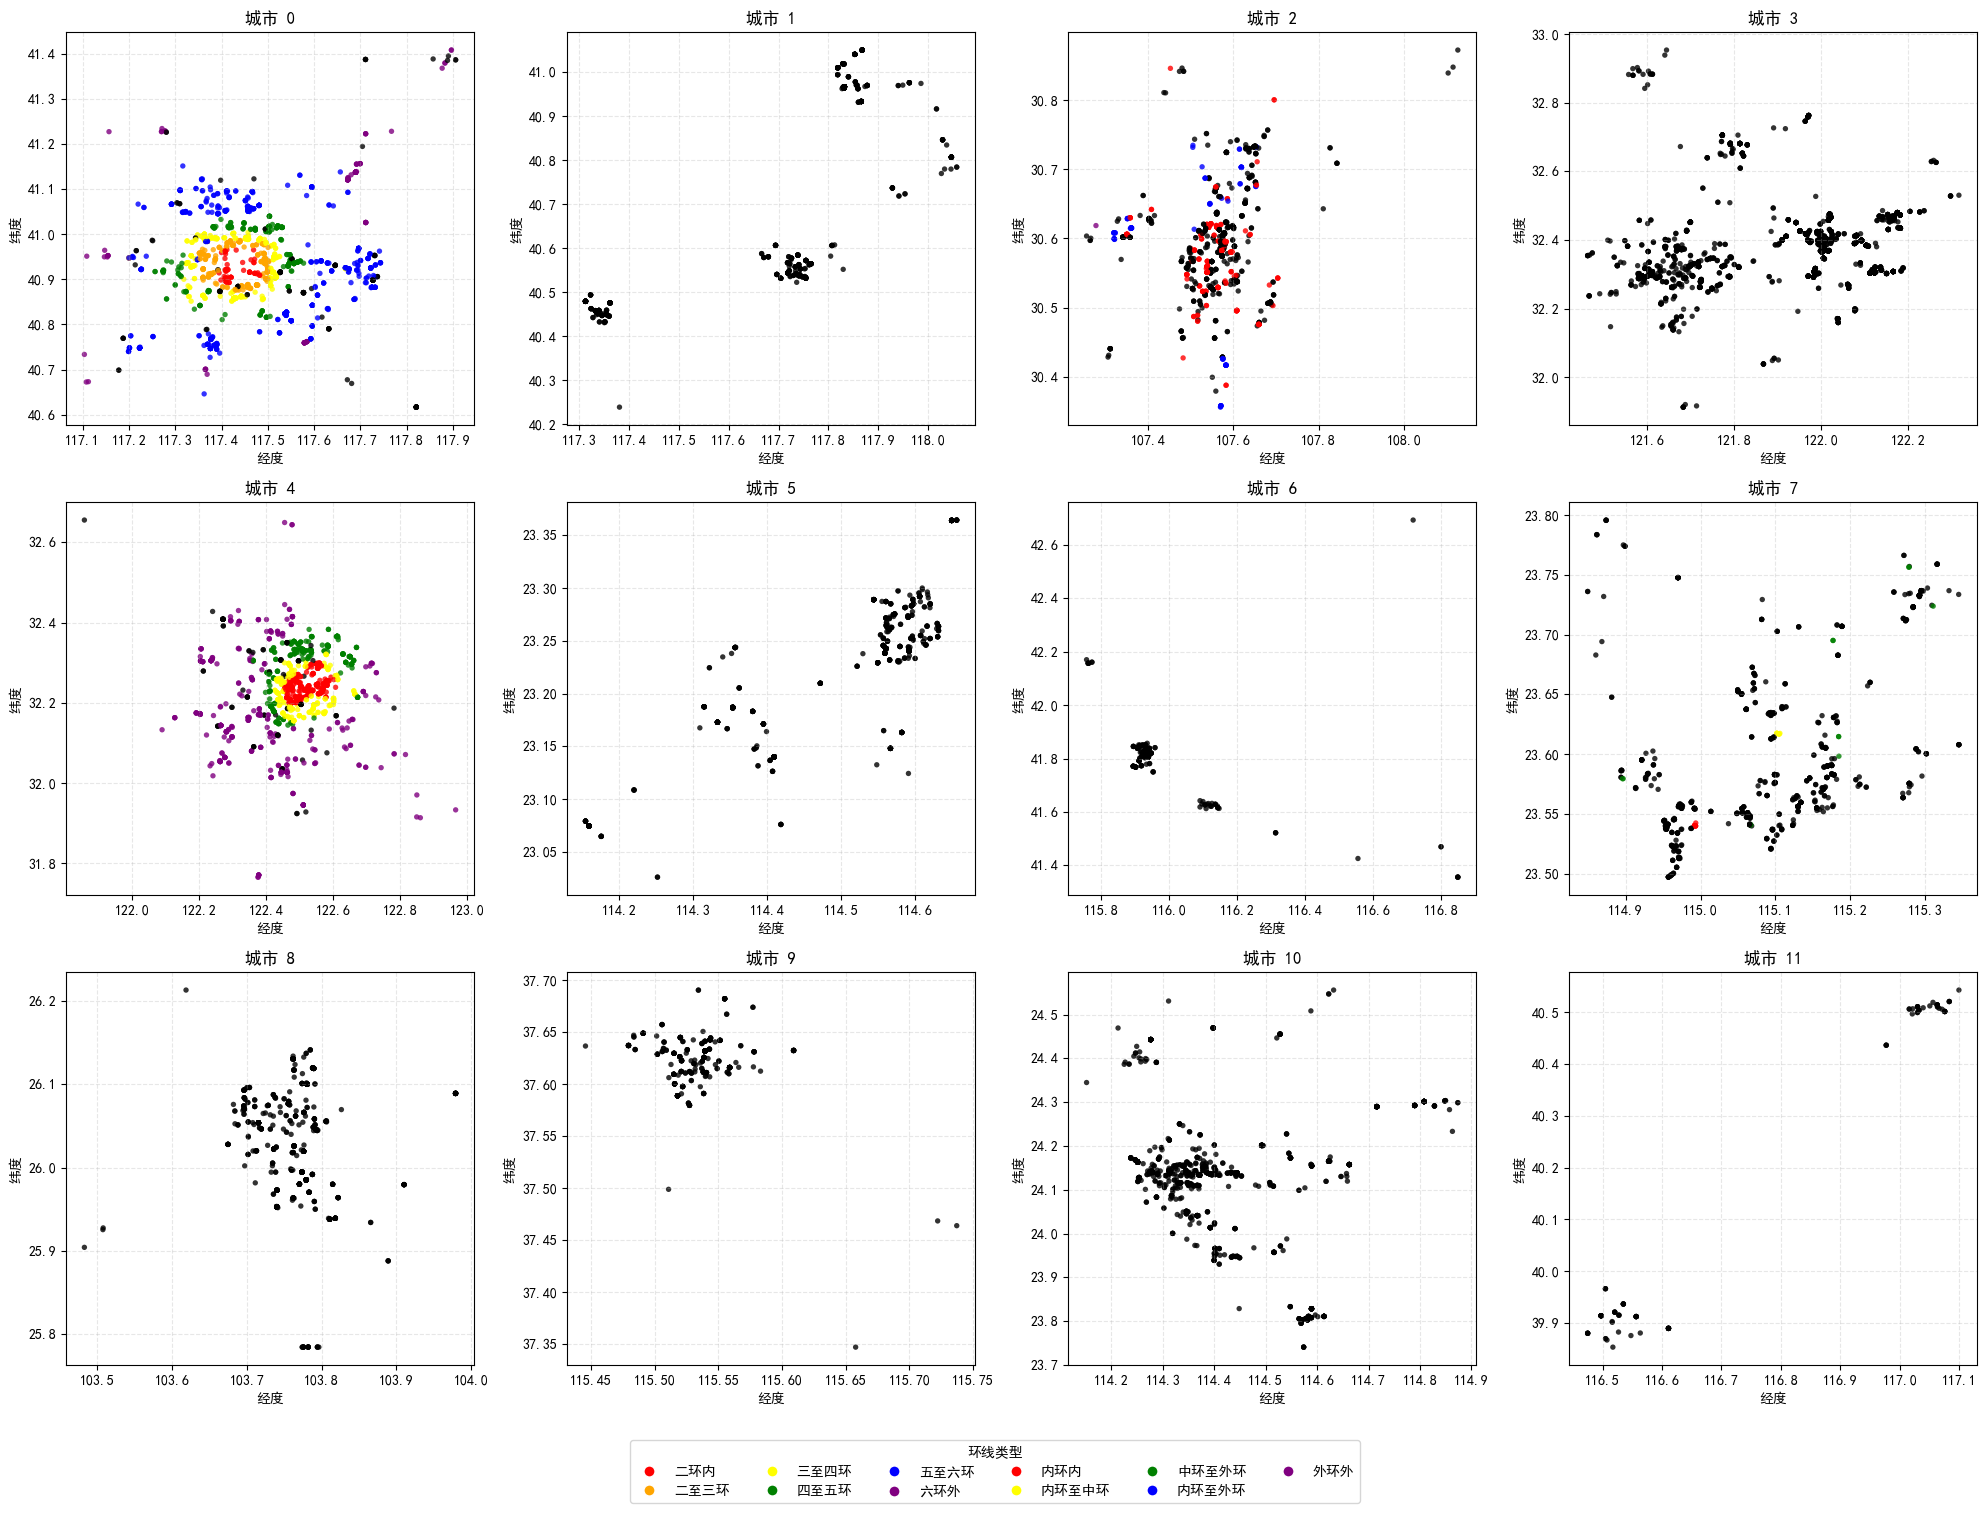

In [17]:
df=df_rent_train

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置Windows中文字体，确保标题和标签正常显示
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

# 1. 定义环线与颜色的映射关系（严格按照需求配置）
color_mapping = {
    # 空白值处理（包含NaN和空字符串）
    np.nan: 'black',
    '': 'black',
    # 环线类型对应颜色
    '二环内': 'red',
    '二至三环': 'orange',
    '三至四环': 'yellow',
    '四至五环': 'green',
    '五至六环': 'blue',
    '六环外': 'purple',
    '内环内': 'red',
    '内环至中环': 'yellow',
    '中环至外环': 'green',
    '内环至外环': 'blue',
    '外环外': 'purple'
}

# 2. 数据预处理
# 确保城市列为整数类型（0-11）
df['城市'] = df['城市'].astype(int)
# 将环线列的空白值统一转换为NaN，便于映射
df['环线位置'] = df['环线位置'].replace('', np.nan)

# 3. 获取所有城市并排序（确保0-11顺序）
cities = sorted(df['城市'].unique())
# 检查是否包含所有12个城市，若有缺失则提示
missing_cities = set(range(12)) - set(cities)
if missing_cities:
    print(f"注意：缺失以下城市的数据：{missing_cities}")

# 4. 创建12个子图（3行4列布局，适合12个城市）
fig, axes = plt.subplots(3, 4, figsize=(20, 15))  # 宽20，高15，保证子图清晰
axes = axes.flatten()  # 转换为一维数组，方便循环遍历

# 5. 逐个城市绘制散点图
for i, city in enumerate(cities):
    # 筛选当前城市的数据
    city_df = df[df['城市'] == city].copy()
    
    # 根据环线列匹配颜色，未匹配的异常值默认黑色
    city_df['点颜色'] = city_df['环线位置'].map(color_mapping).fillna('black')
    
    # 绘制散点图：x=经度，y=纬度，颜色按环线规则
    axes[i].scatter(
        city_df['lon'], 
        city_df['lat'], 
        c=city_df['点颜色'],  # 点的颜色
        s=15,  # 点的大小（可根据数据量调整）
        alpha=0.8,  # 透明度（避免重叠过密）
        edgecolor='none'  # 无边框，突出颜色区分
    )
    
    # 设置子图标题和坐标轴标签
    axes[i].set_title(f'城市 {city}', fontsize=12)
    axes[i].set_xlabel('经度', fontsize=10)
    axes[i].set_ylabel('纬度', fontsize=10)
    axes[i].grid(linestyle='--', alpha=0.3)  # 浅色网格线，不干扰数据

# 6. 添加统一图例（解释颜色对应的环线类型）
# 提取非空白的环线类型和对应颜色（去重）
legend_items = {k: v for k, v in color_mapping.items() if k not in [np.nan, '']}
# 创建图例手柄
handles = [plt.Line2D(
    [0], [0], 
    marker='o', 
    color='w', 
    markerfacecolor=color, 
    markersize=8, 
    label=label
) for label, color in legend_items.items()]
# 放置图例（底部居中，6列分布）
fig.legend(
    handles=handles, 
    title='环线类型', 
    loc='lower center', 
    ncol=6, 
    bbox_to_anchor=(0.5, -0.01), 
    fontsize=10
)

# 调整布局，避免图例和子图重叠
plt.tight_layout(rect=[0, 0.05, 1, 1])  # 预留底部5%空间放图例
plt.show()

===== 数据基本信息 =====
总样本数：9773
环线数值非空样本数：2811
环线数值空缺样本数：6962
包含的城市列表：[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

开始批量处理所有城市，共12个城市...


===== 处理城市 0 =====
样本总数：1512
已知环线样本：1387
需填充样本：125
填充后有效样本数：1512（完成率：100.00%）


C:\Users\杨\AppData\Local\Temp\ipykernel_25592\2000342585.py:95: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dist = planar_distance(row['lat_rel'], row['lon_rel'], center[0], center[1])


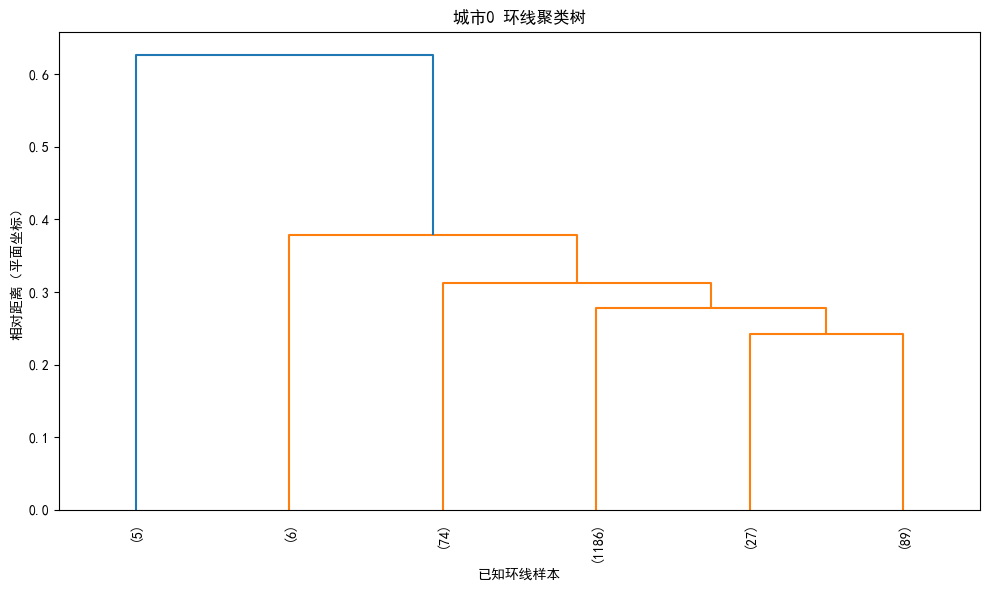

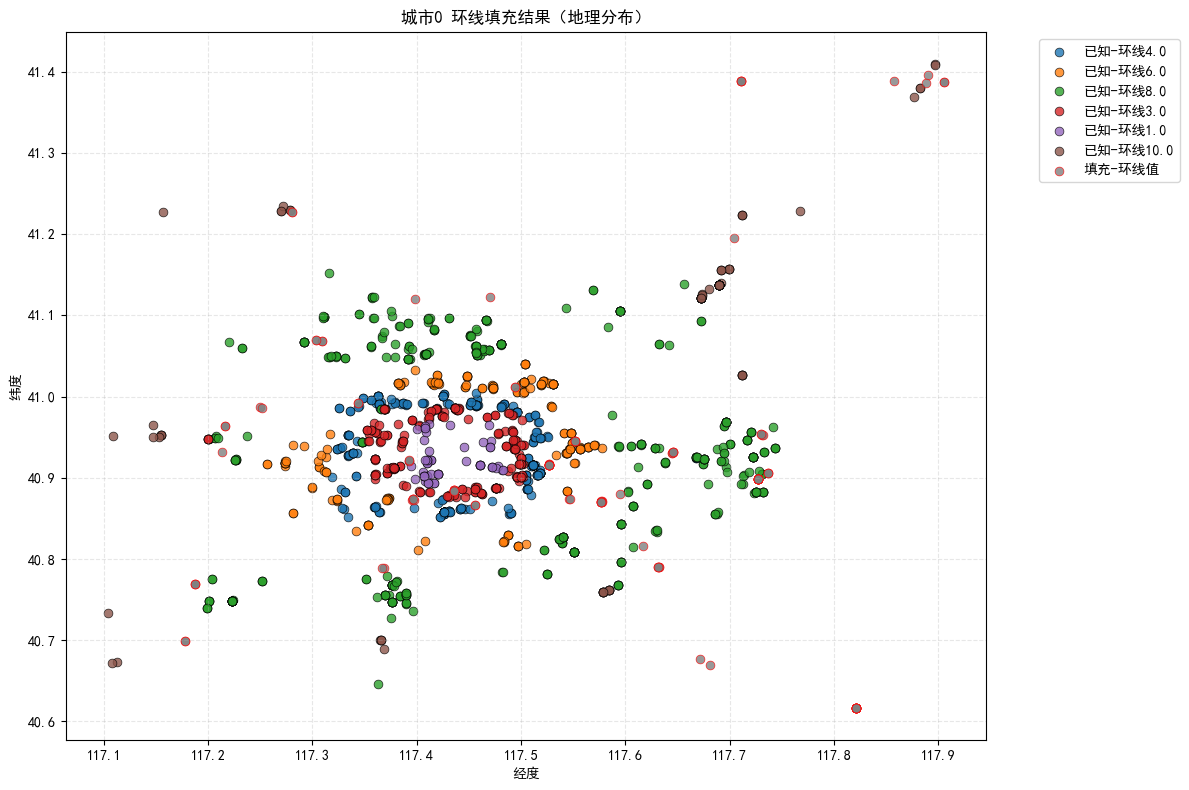


----- 处理城市0的区域 5.0 -----
区域样本数：33
区域环线分布：[np.float64(1.0), np.float64(3.0)]


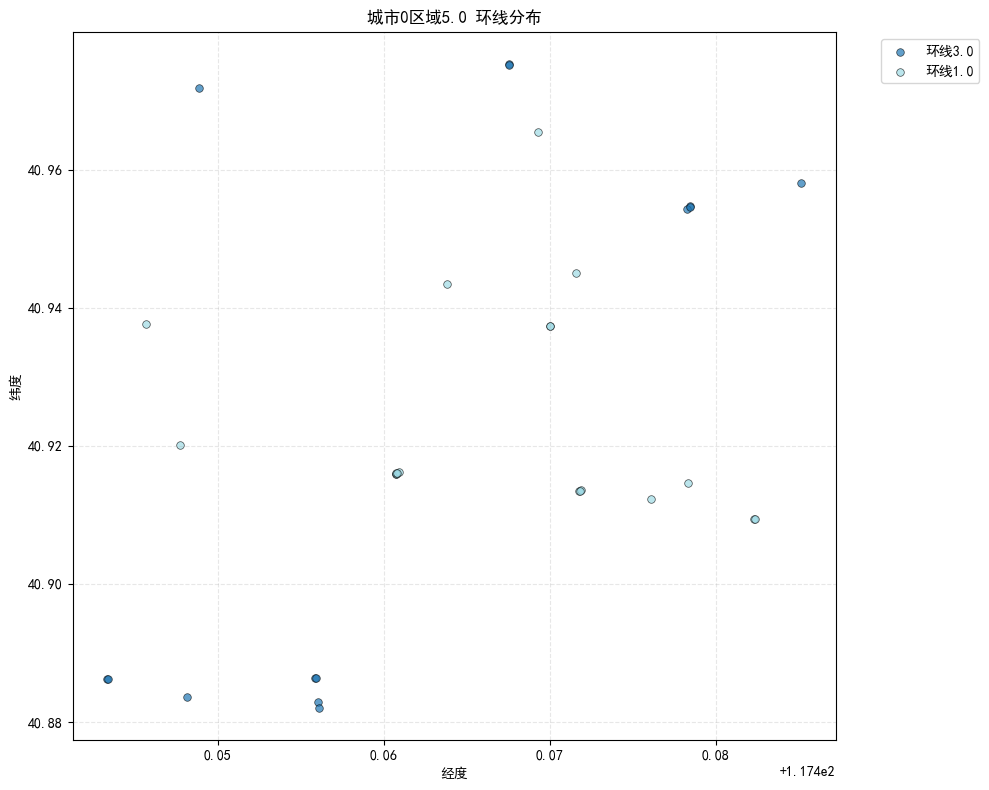

----- 处理区域5.0的板块 44.0 -----
板块样本数：1
板块环线分布：[np.float64(1.0)]


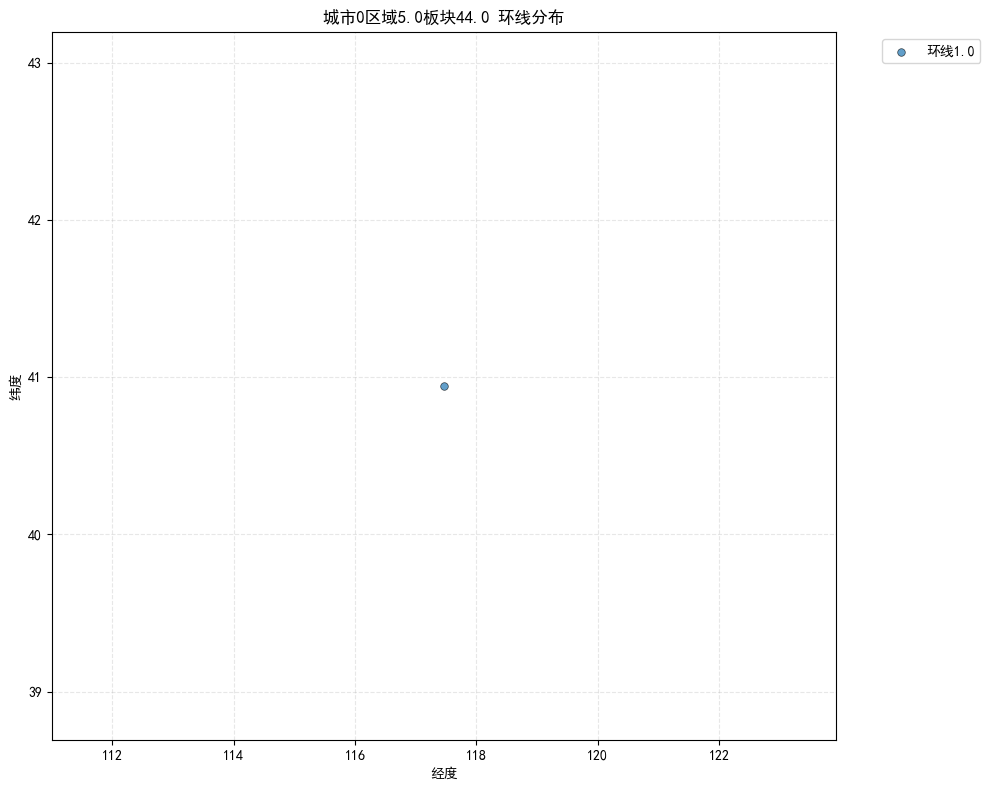


===== 处理城市 1 =====
样本总数：567
已知环线样本：0
需填充样本：567
警告：城市1无已知环线数据，无法填充
填充后有效样本数：0（完成率：0.00%）


C:\Users\杨\AppData\Local\Temp\ipykernel_25592\2000342585.py:142: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


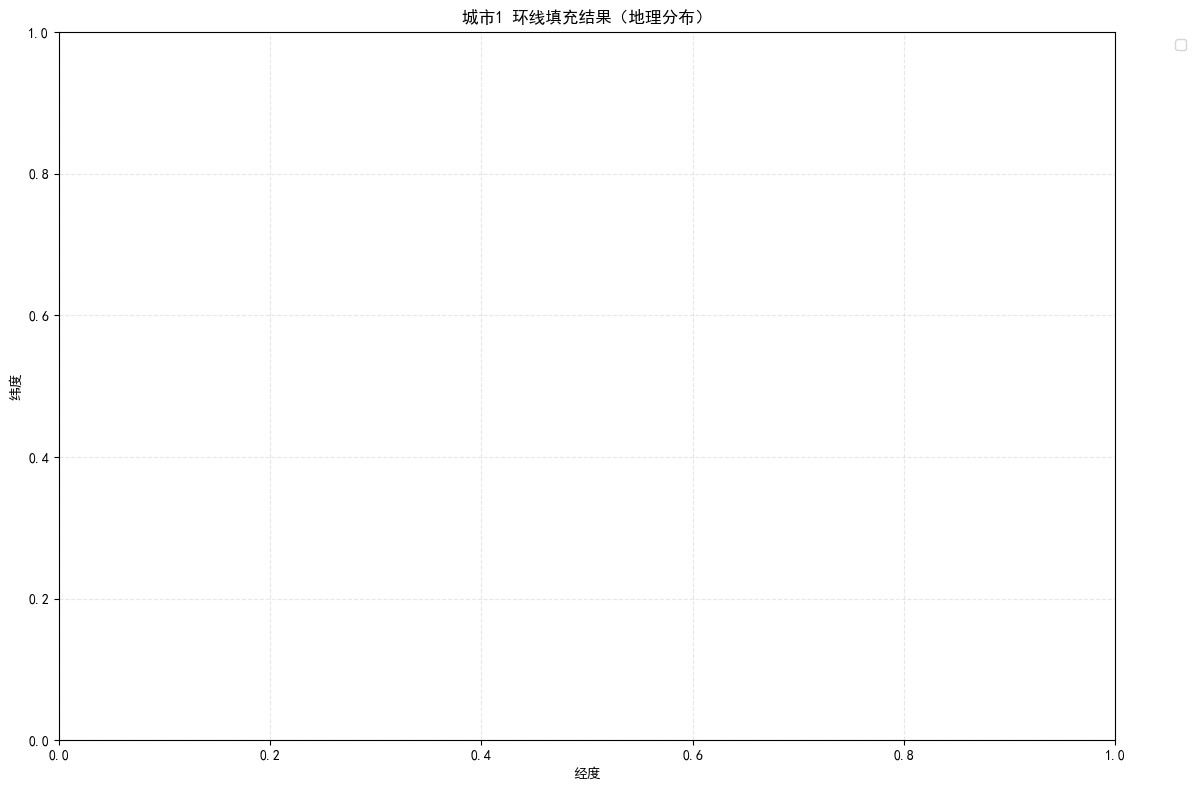


----- 处理城市1的区域 24.0 -----
区域样本数：112
区域环线分布：[np.float64(nan)]


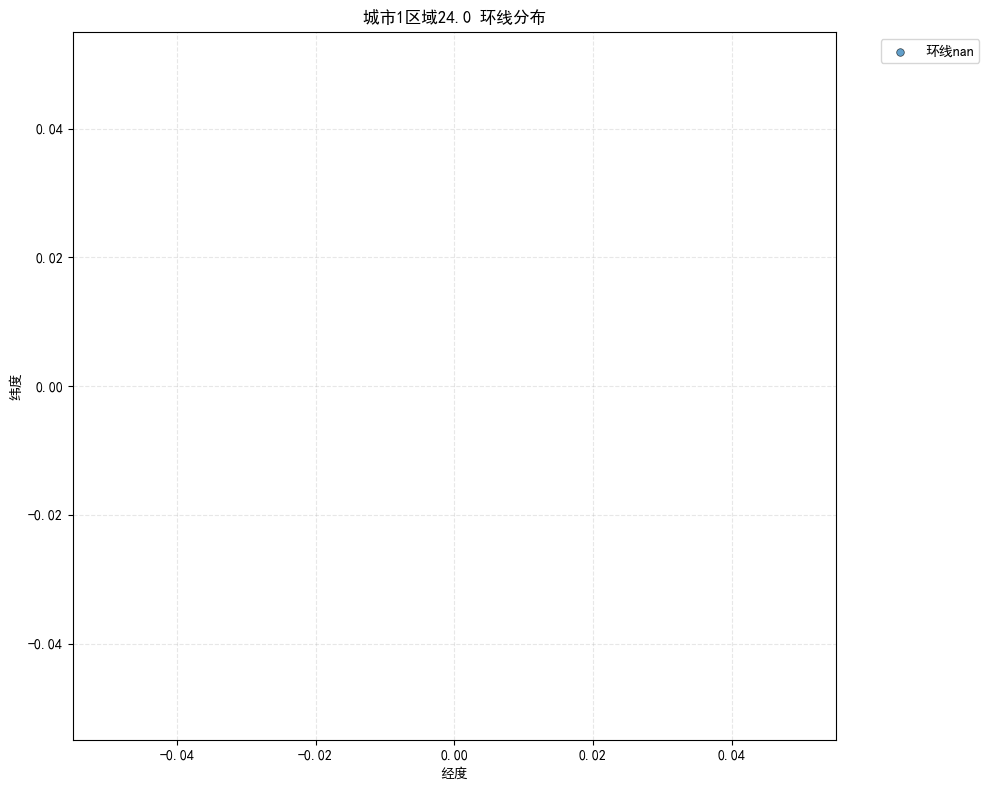

----- 处理区域24.0的板块 303.0 -----
板块样本数：112
板块环线分布：[np.float64(nan)]


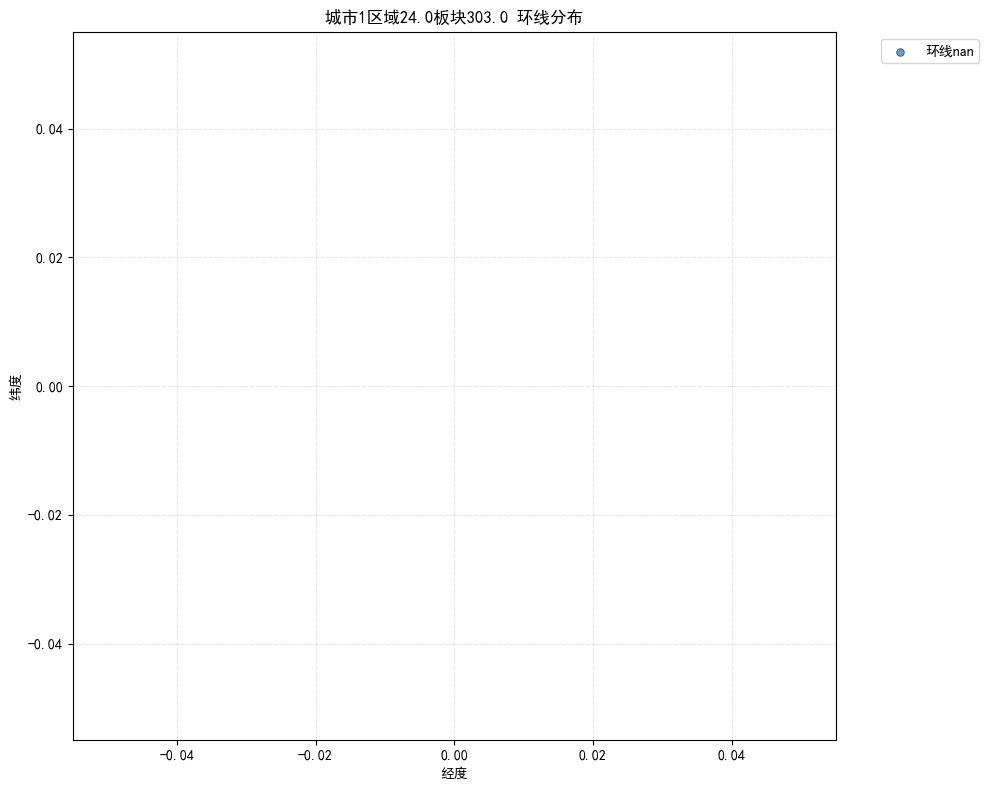


===== 处理城市 2 =====
样本总数：936
已知环线样本：316
需填充样本：620
填充后有效样本数：936（完成率：100.00%）


C:\Users\杨\AppData\Local\Temp\ipykernel_25592\2000342585.py:95: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dist = planar_distance(row['lat_rel'], row['lon_rel'], center[0], center[1])


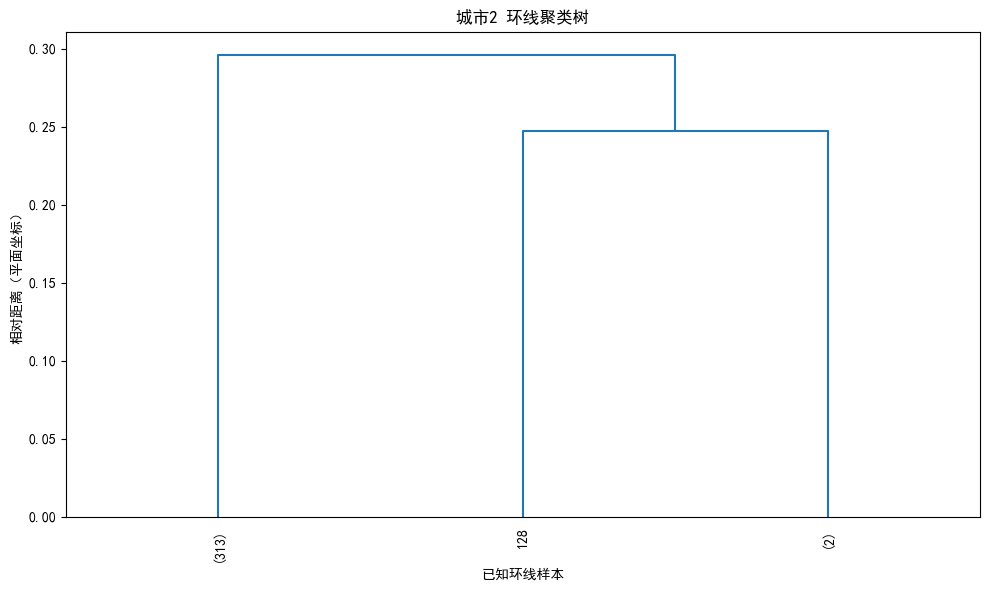

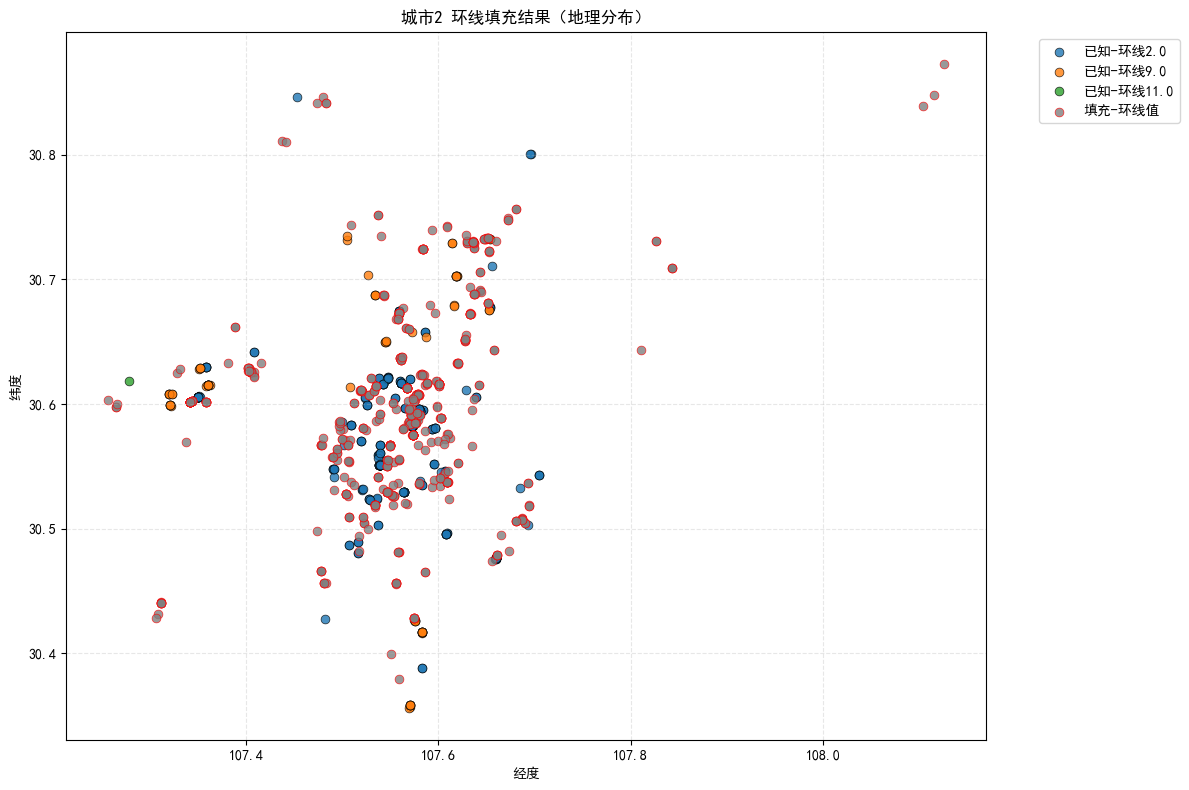


----- 处理城市2的区域 9.0 -----
区域样本数：108
区域环线分布：[np.float64(2.0)]


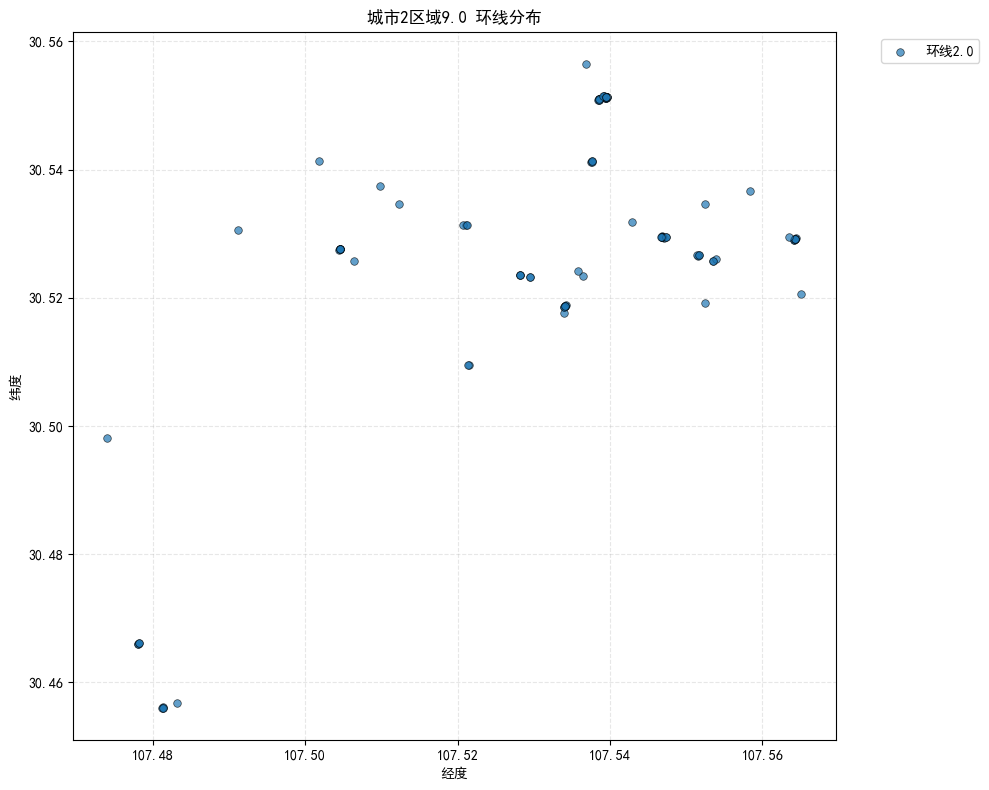

----- 处理区域9.0的板块 106.0 -----
板块样本数：9
板块环线分布：[np.float64(2.0)]


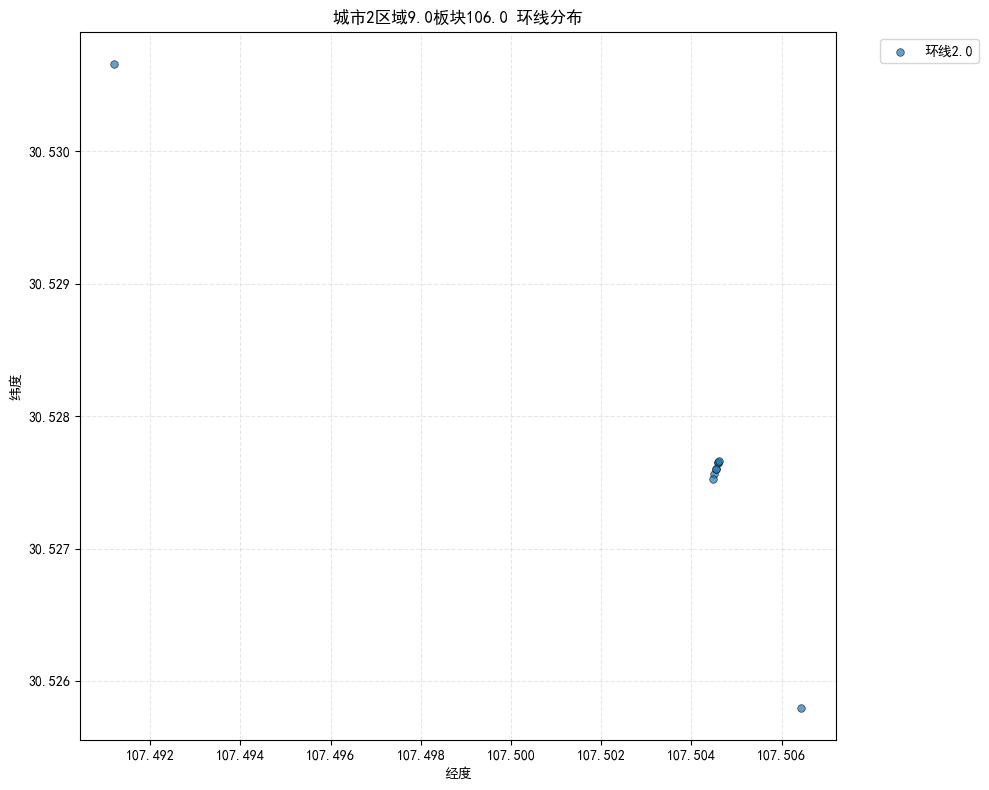


===== 处理城市 3 =====
样本总数：1802
已知环线样本：0
需填充样本：1802
警告：城市3无已知环线数据，无法填充
填充后有效样本数：0（完成率：0.00%）


C:\Users\杨\AppData\Local\Temp\ipykernel_25592\2000342585.py:142: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


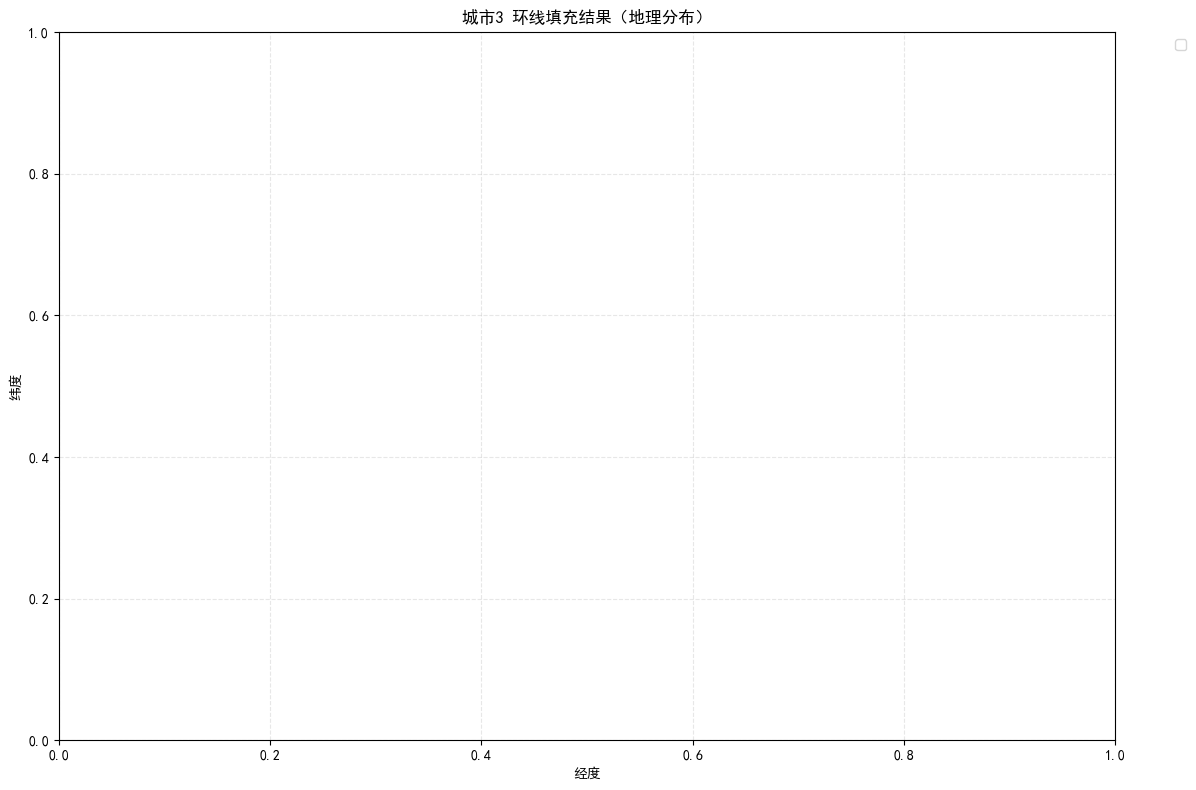


----- 处理城市3的区域 20.0 -----
区域样本数：112
区域环线分布：[np.float64(nan)]


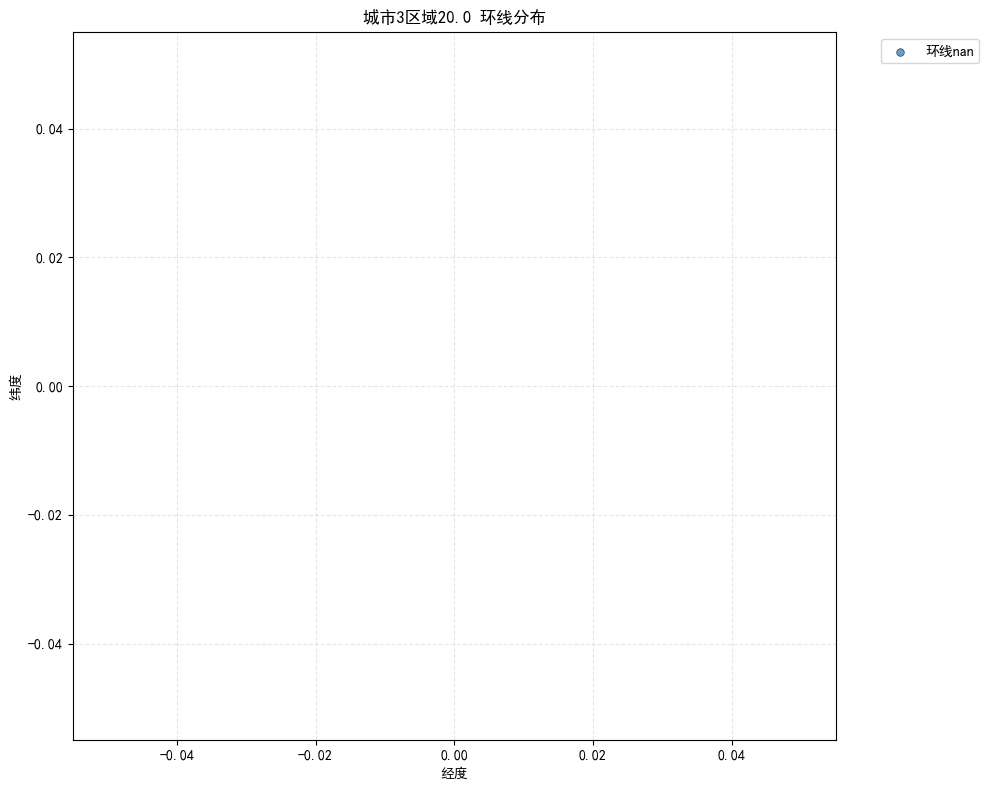

----- 处理区域20.0的板块 89.0 -----
板块样本数：1
板块环线分布：[np.float64(nan)]


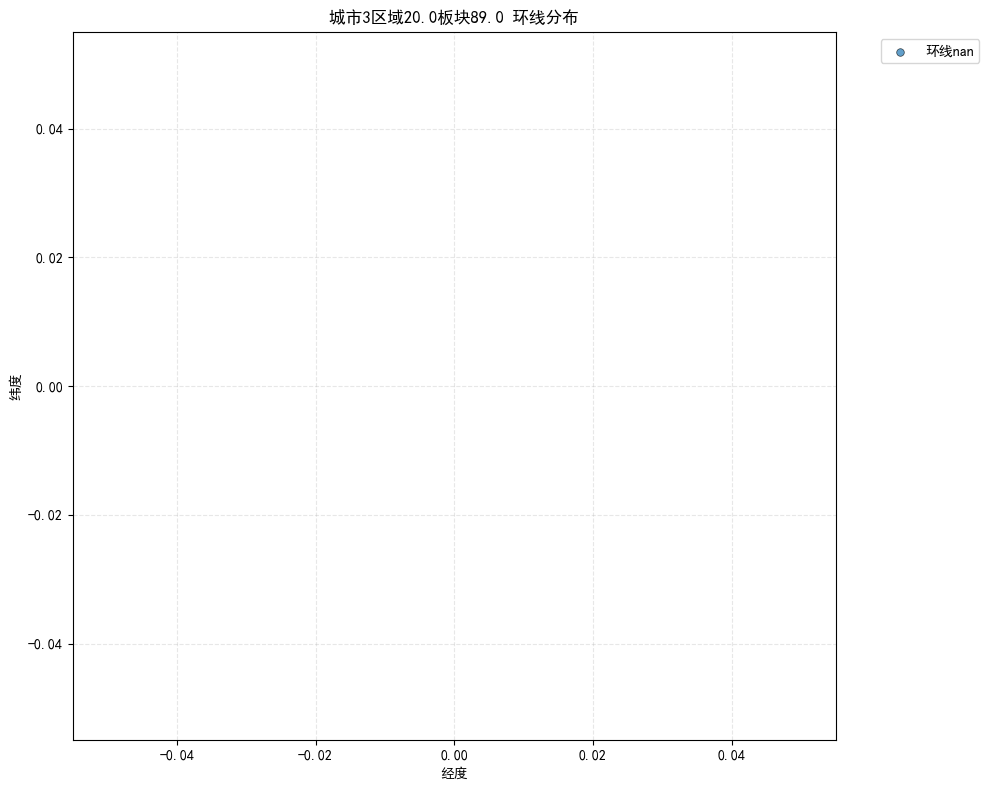


===== 处理城市 4 =====
样本总数：1168
已知环线样本：1077
需填充样本：91
填充后有效样本数：1168（完成率：100.00%）


C:\Users\杨\AppData\Local\Temp\ipykernel_25592\2000342585.py:95: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dist = planar_distance(row['lat_rel'], row['lon_rel'], center[0], center[1])


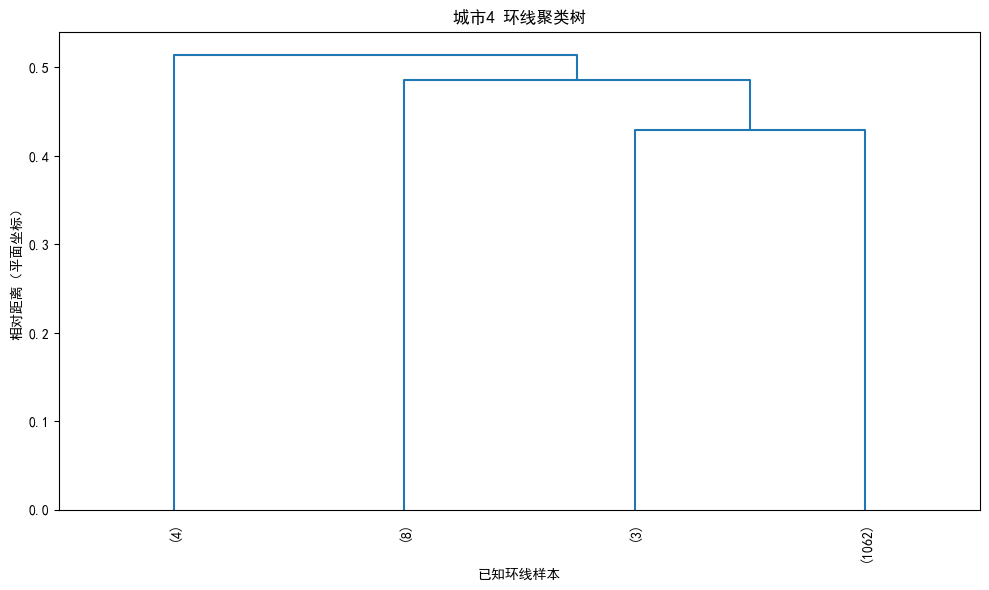

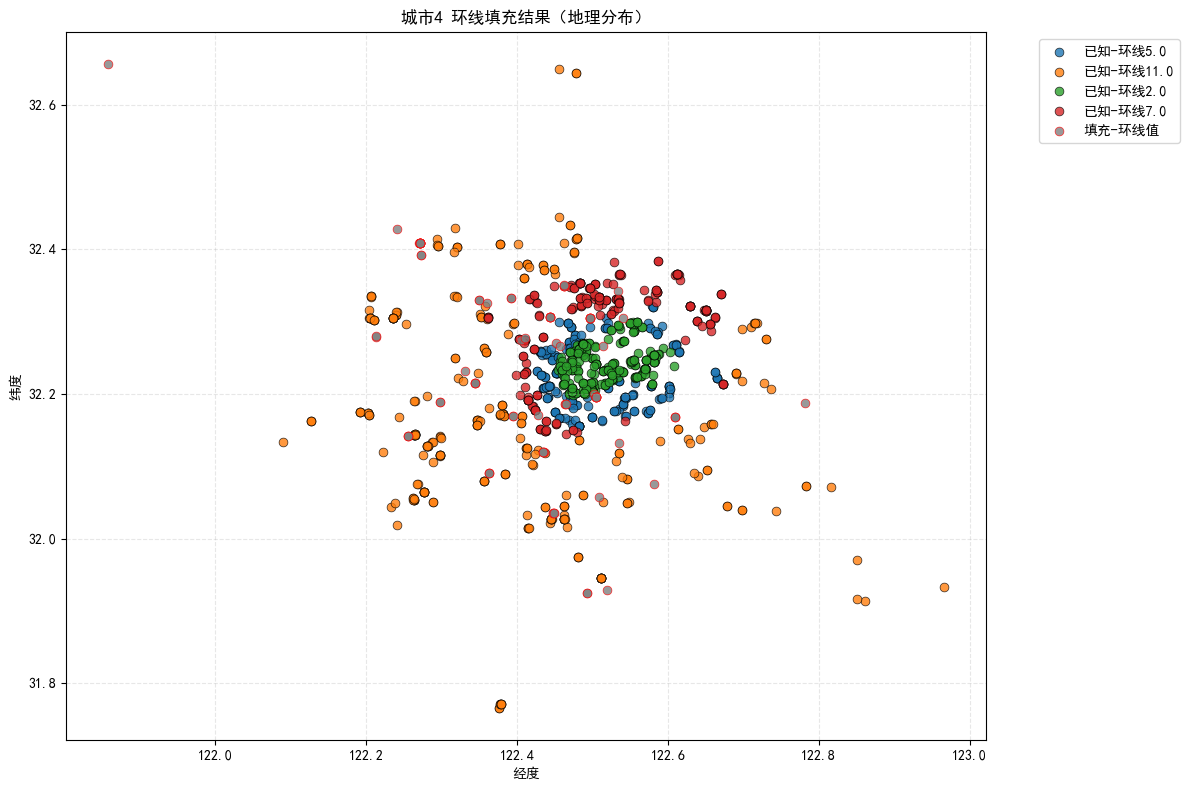


----- 处理城市4的区域 23.0 -----
区域样本数：66
区域环线分布：[np.float64(2.0), np.float64(7.0), np.float64(11.0)]


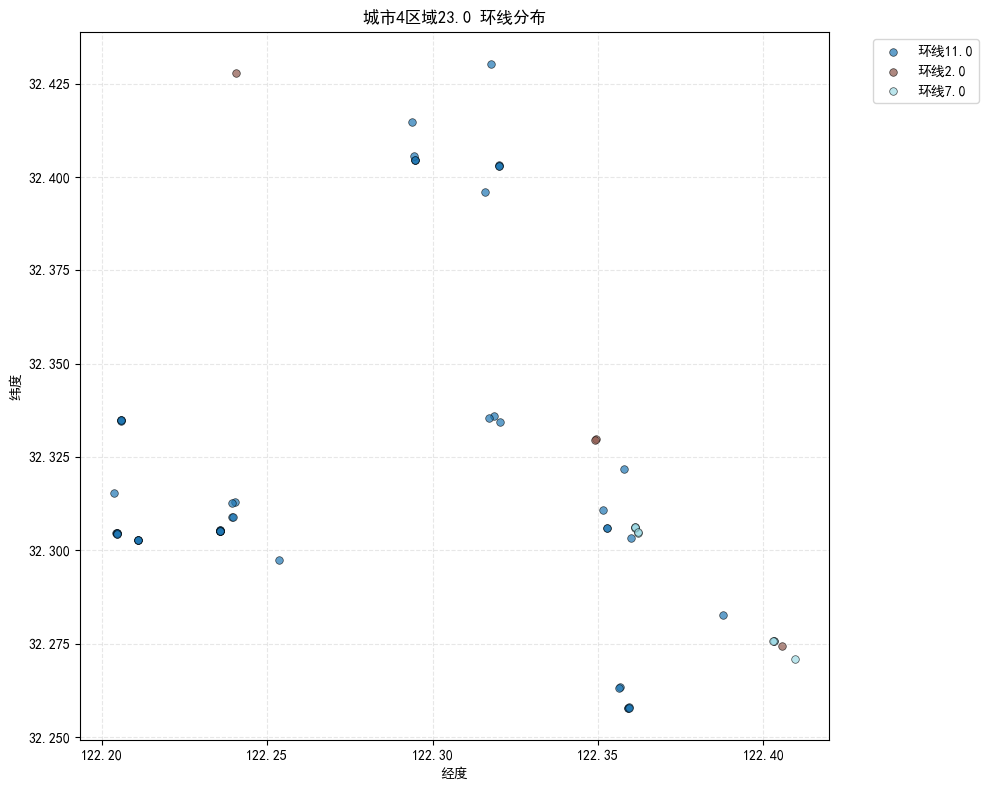

----- 处理区域23.0的板块 85.0 -----
板块样本数：5
板块环线分布：[np.float64(2.0), np.float64(7.0)]


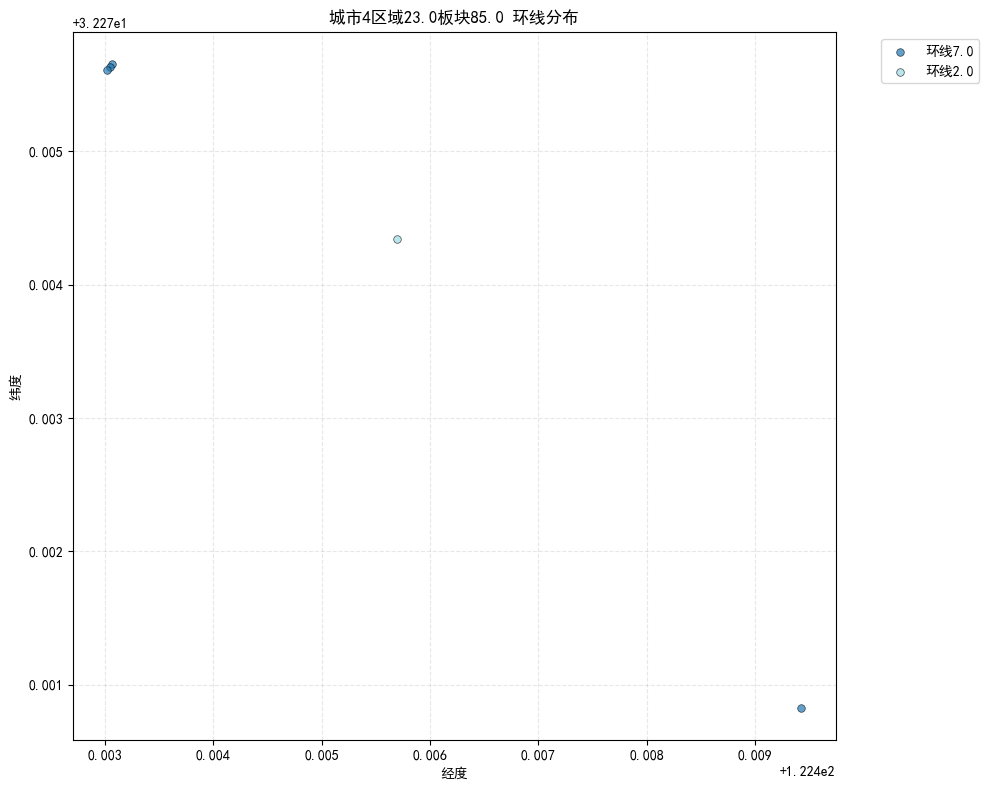


===== 处理城市 5 =====
样本总数：592
已知环线样本：0
需填充样本：592
警告：城市5无已知环线数据，无法填充
填充后有效样本数：0（完成率：0.00%）


C:\Users\杨\AppData\Local\Temp\ipykernel_25592\2000342585.py:142: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


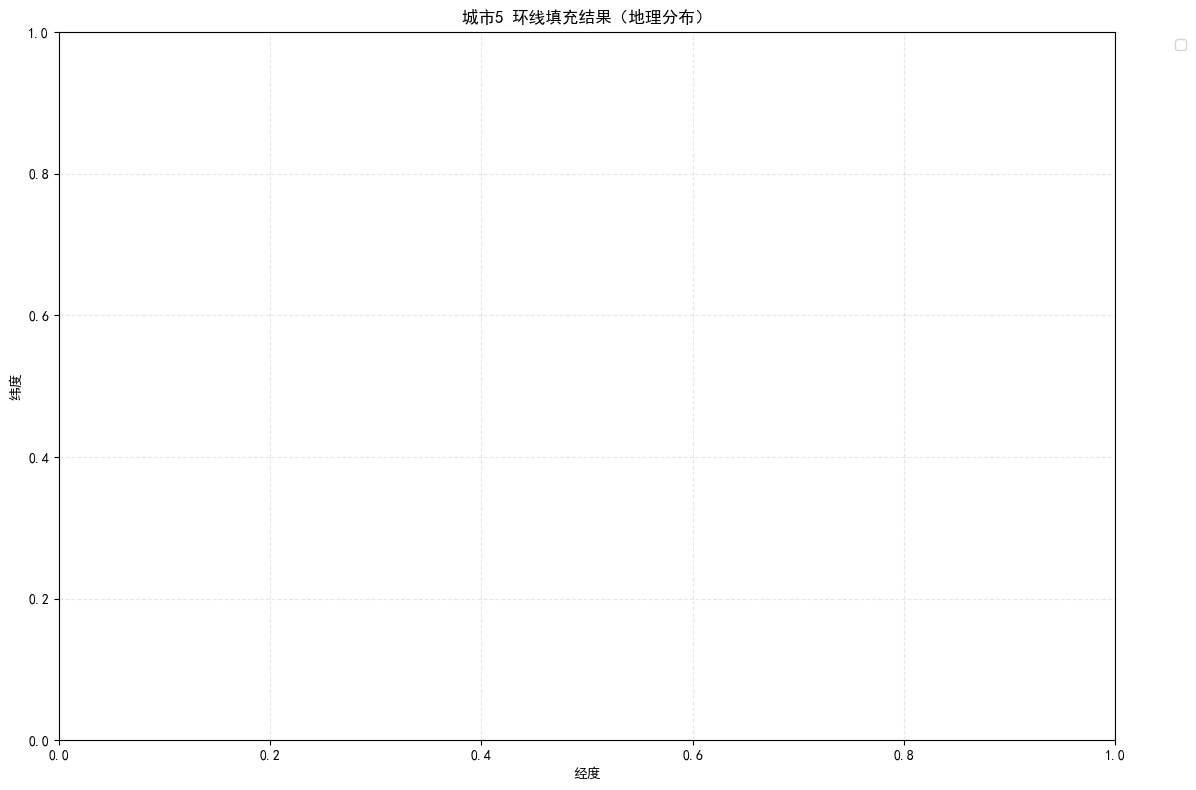


----- 处理城市5的区域 63.0 -----
区域样本数：77
区域环线分布：[np.float64(nan)]


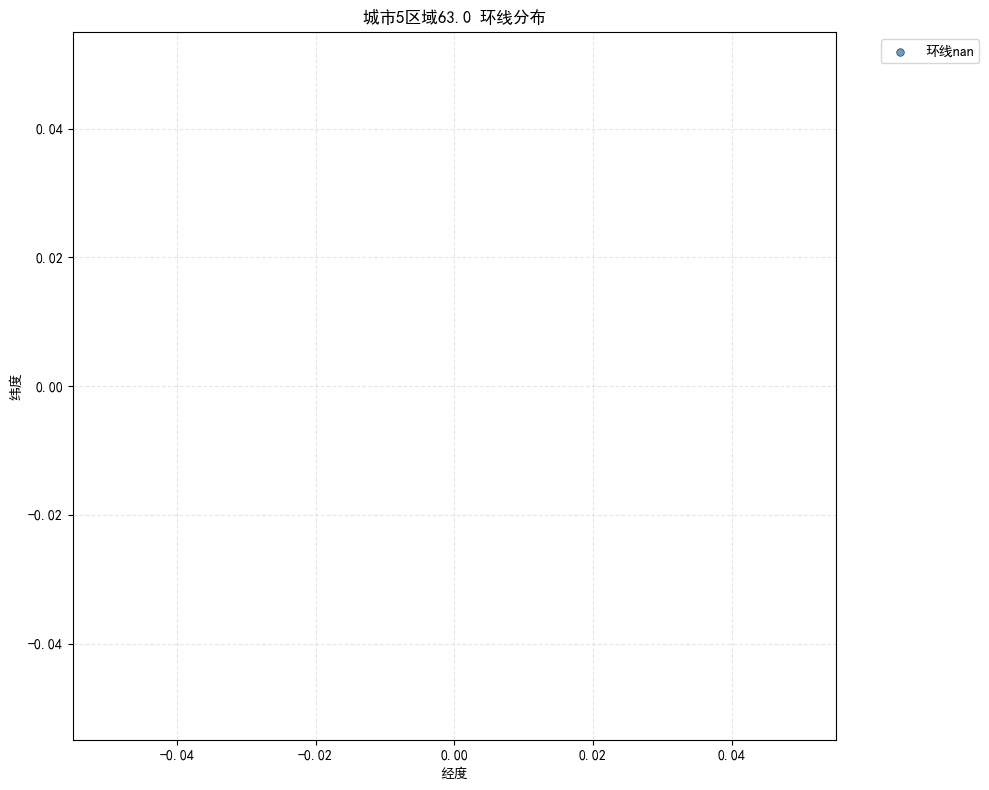

----- 处理区域63.0的板块 117.0 -----
板块样本数：38
板块环线分布：[np.float64(nan)]


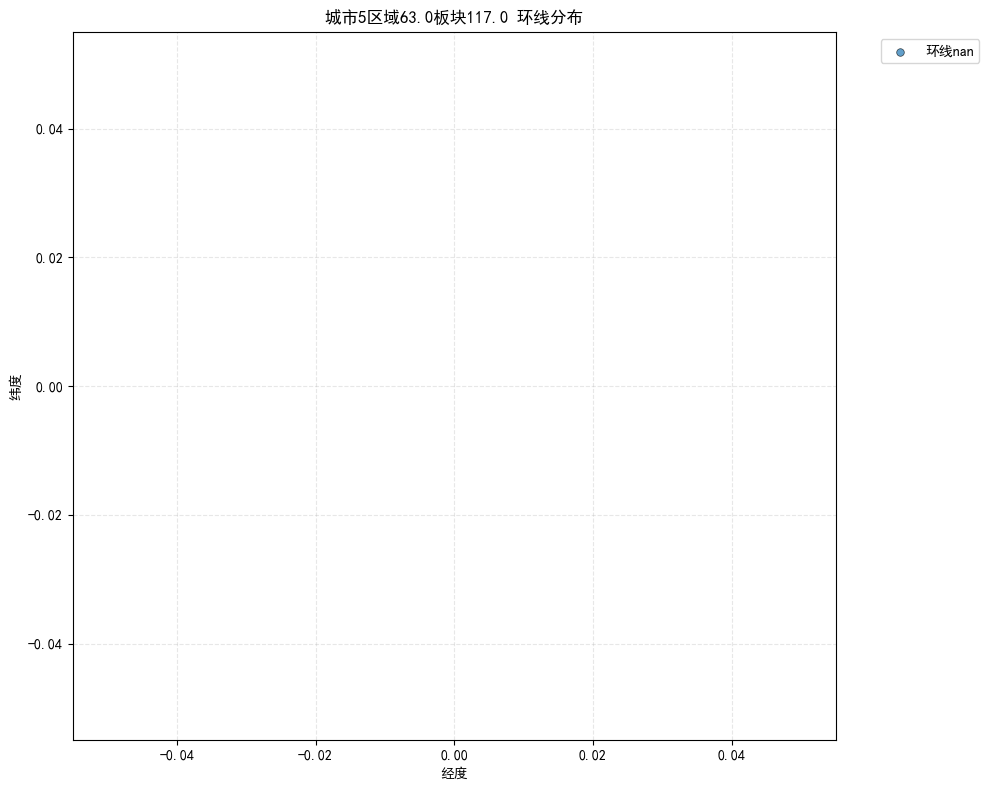


===== 处理城市 6 =====
样本总数：188
已知环线样本：0
需填充样本：188
警告：城市6无已知环线数据，无法填充
填充后有效样本数：0（完成率：0.00%）


C:\Users\杨\AppData\Local\Temp\ipykernel_25592\2000342585.py:142: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


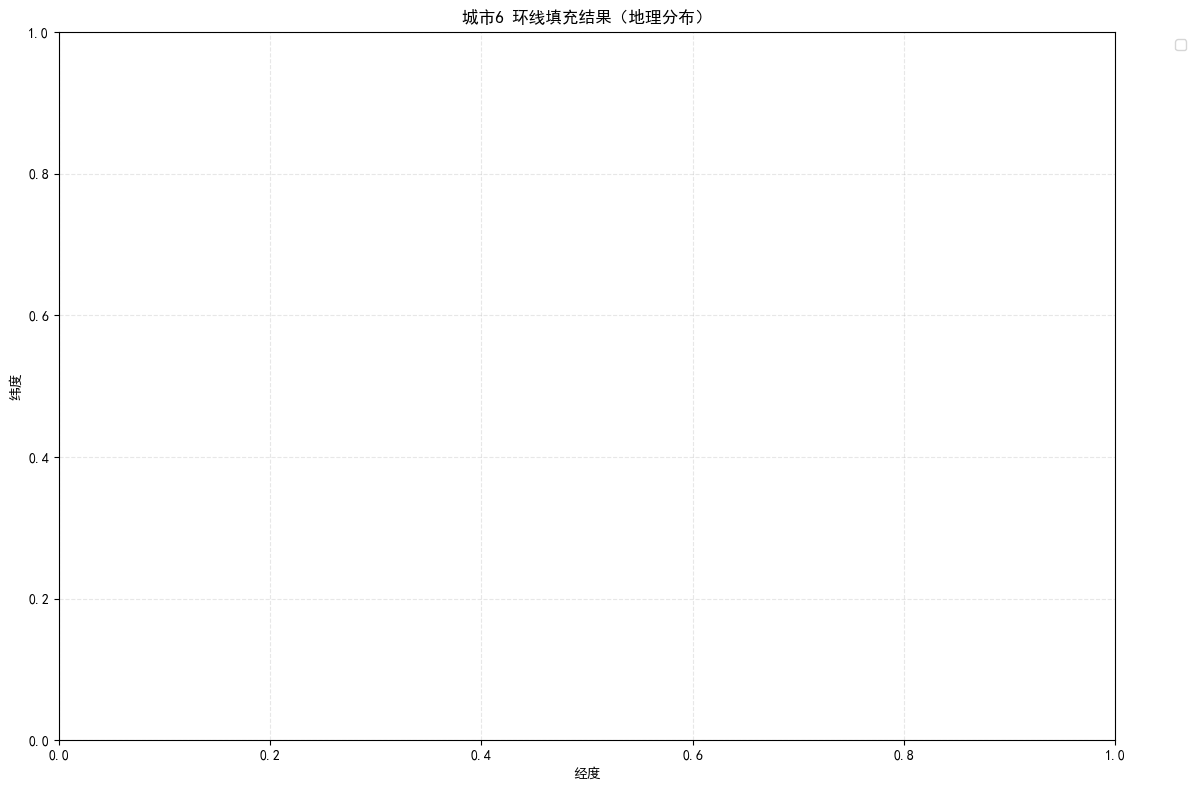


----- 处理城市6的区域 3.0 -----
区域样本数：3
区域环线分布：[np.float64(nan)]


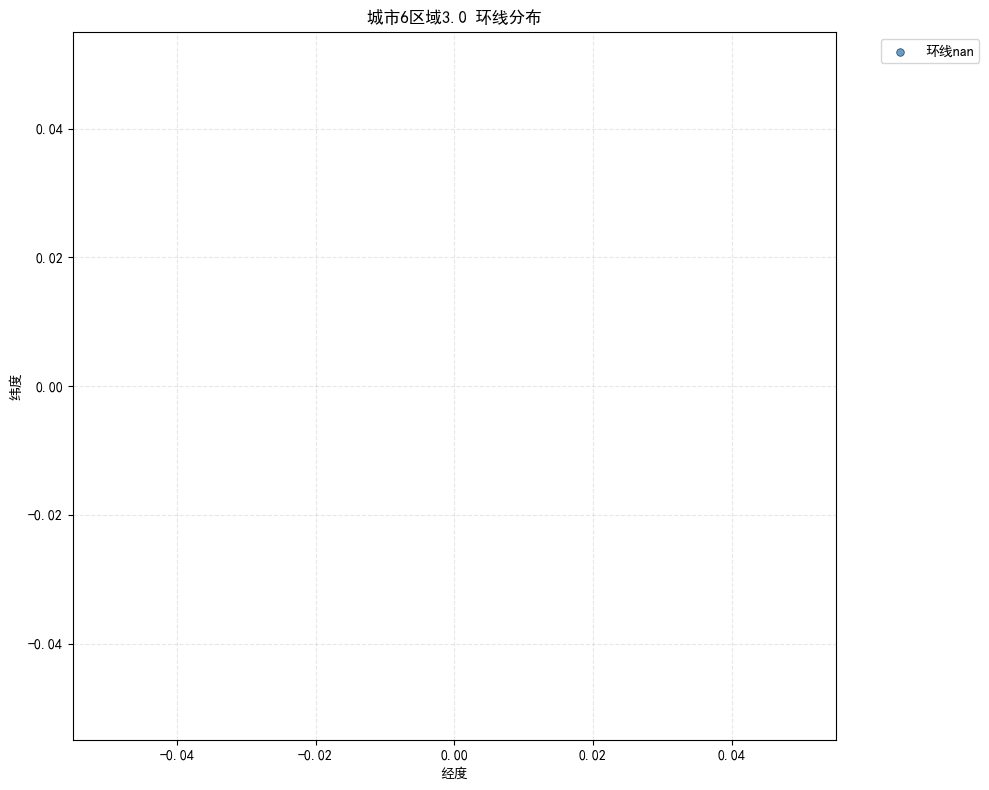

----- 处理区域3.0的板块 35.0 -----
板块样本数：3
板块环线分布：[np.float64(nan)]


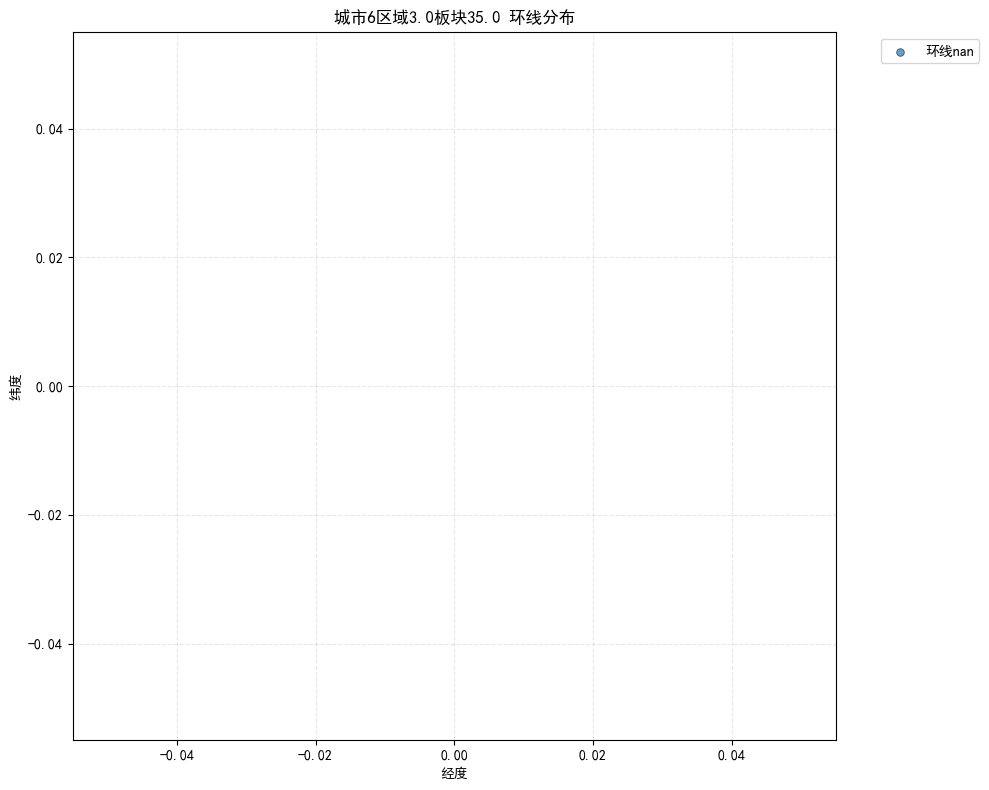


===== 处理城市 7 =====
样本总数：837
已知环线样本：31
需填充样本：806
填充后有效样本数：837（完成率：100.00%）


C:\Users\杨\AppData\Local\Temp\ipykernel_25592\2000342585.py:95: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dist = planar_distance(row['lat_rel'], row['lon_rel'], center[0], center[1])


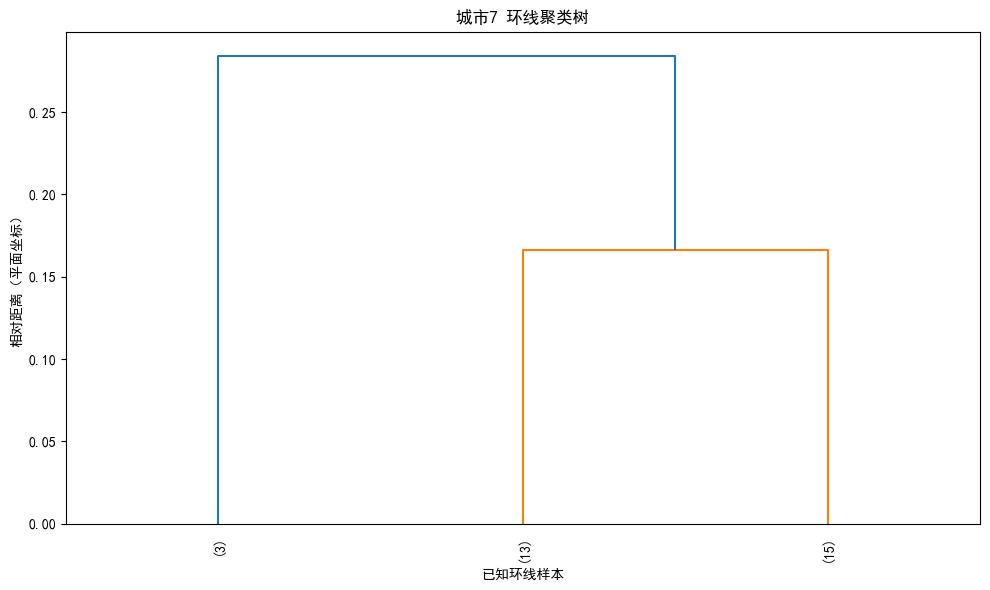

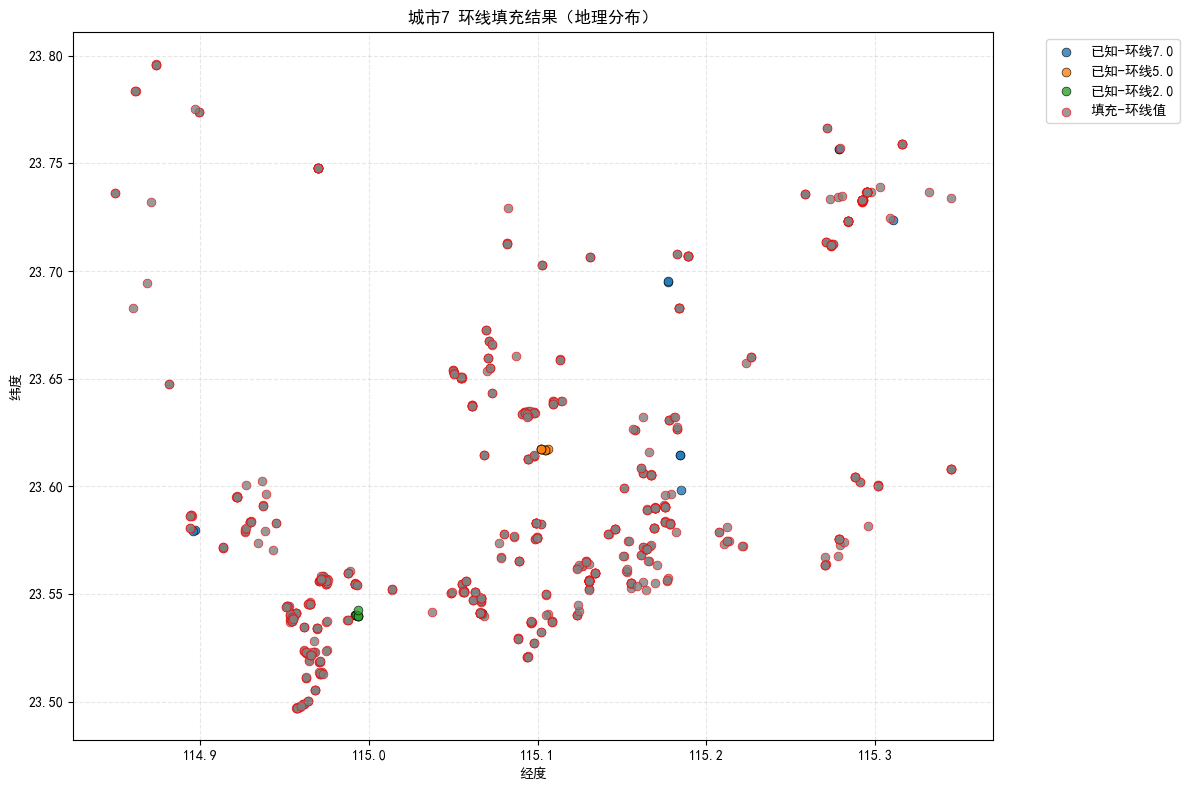


----- 处理城市7的区域 13.0 -----
区域样本数：11
区域环线分布：[np.float64(5.0)]


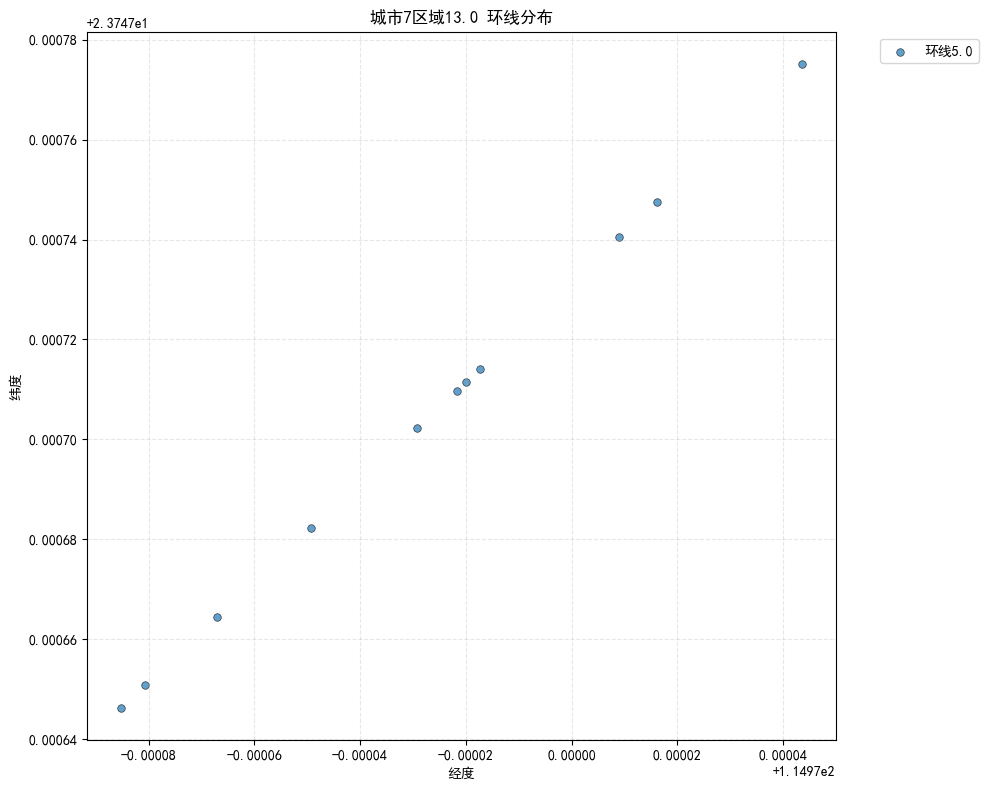

----- 处理区域13.0的板块 147.0 -----
板块样本数：11
板块环线分布：[np.float64(5.0)]


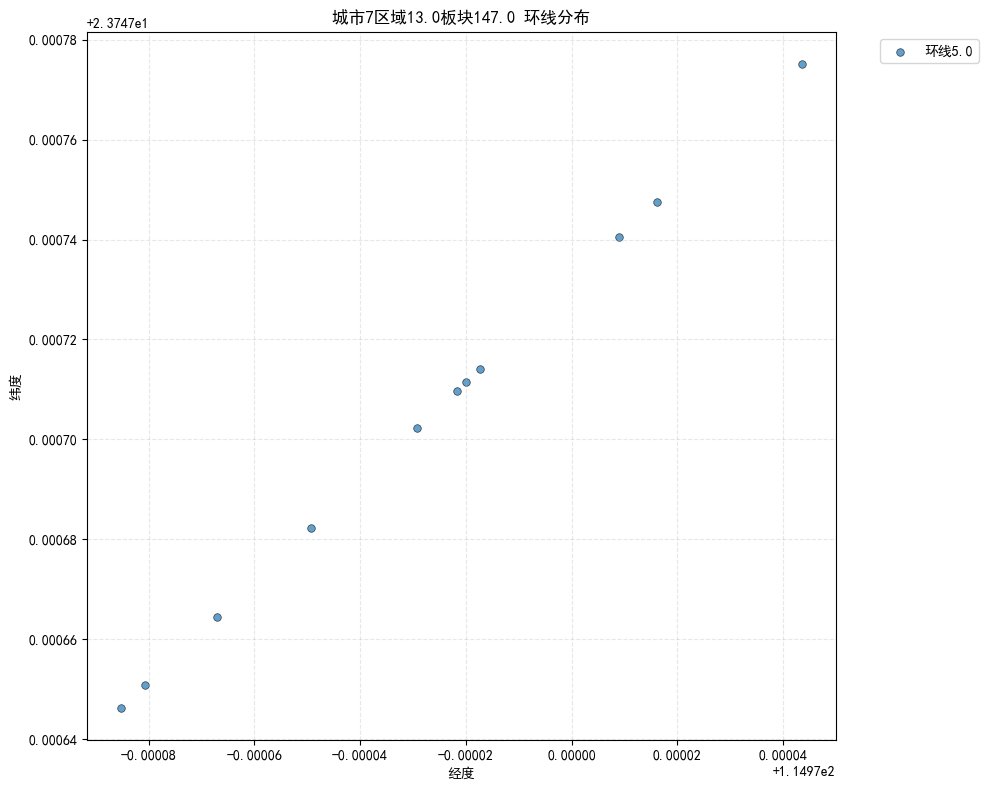


===== 处理城市 8 =====
样本总数：668
已知环线样本：0
需填充样本：668
警告：城市8无已知环线数据，无法填充
填充后有效样本数：0（完成率：0.00%）


C:\Users\杨\AppData\Local\Temp\ipykernel_25592\2000342585.py:142: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


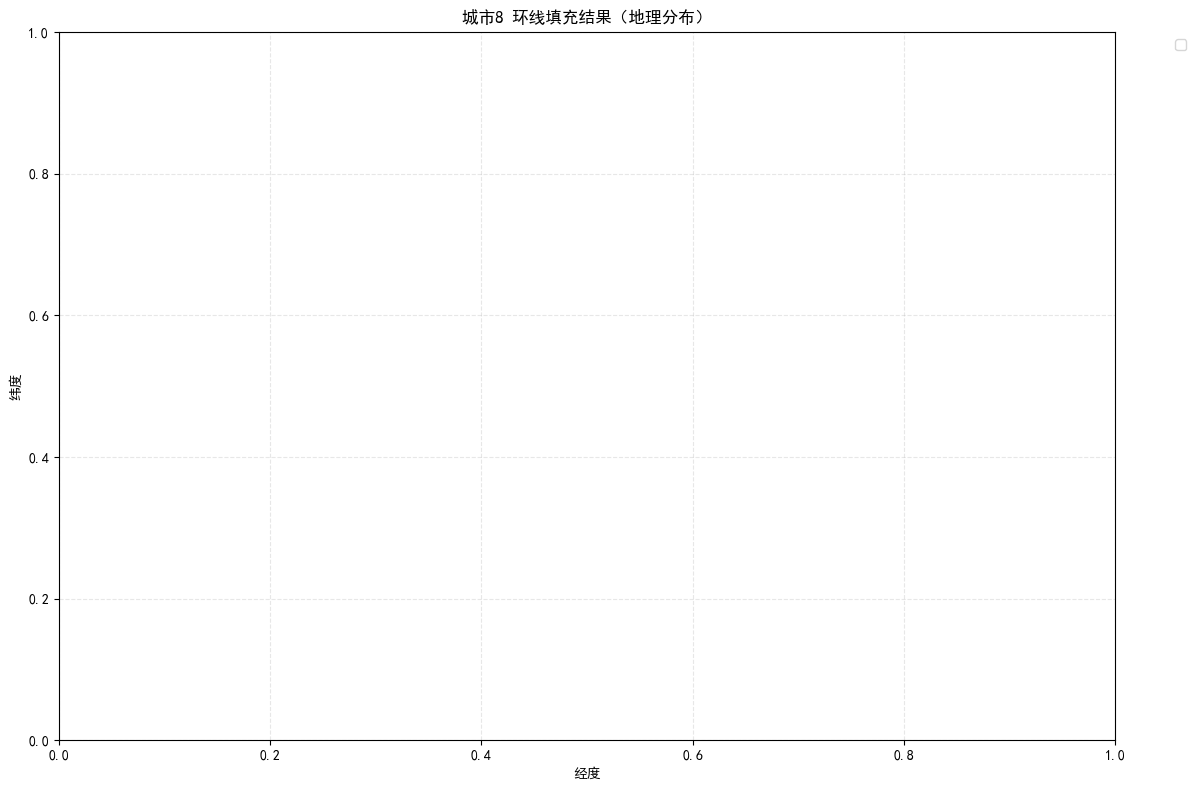


----- 处理城市8的区域 10.0 -----
区域样本数：91
区域环线分布：[np.float64(nan)]


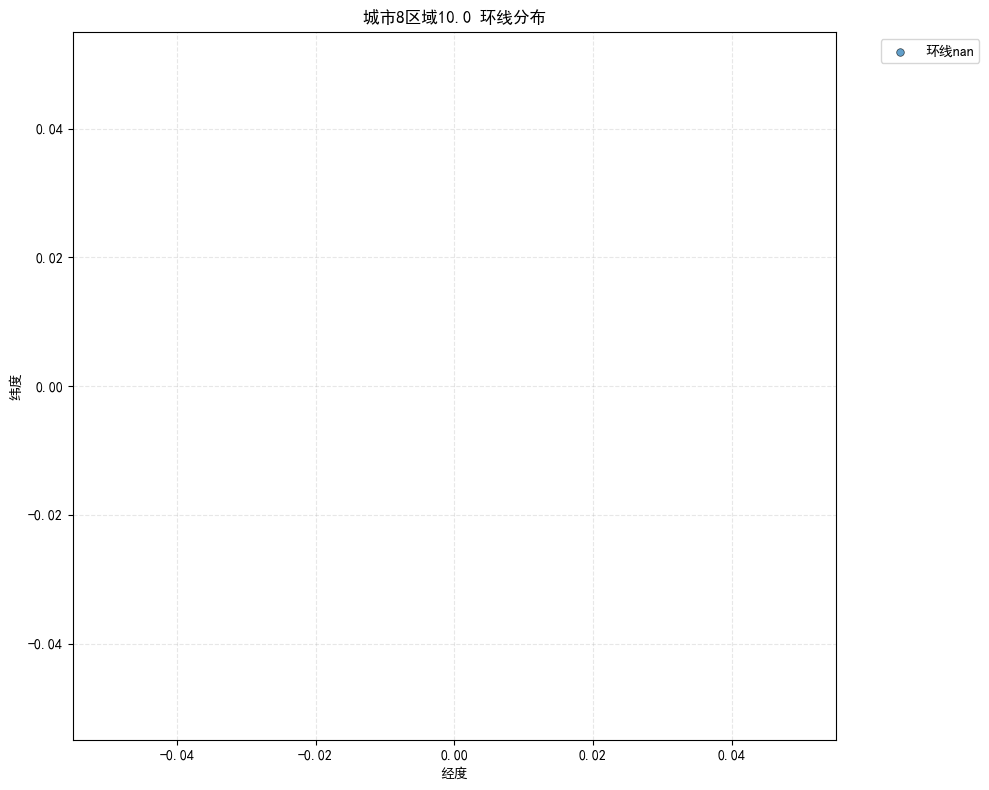

----- 处理区域10.0的板块 84.0 -----
板块样本数：5
板块环线分布：[np.float64(nan)]


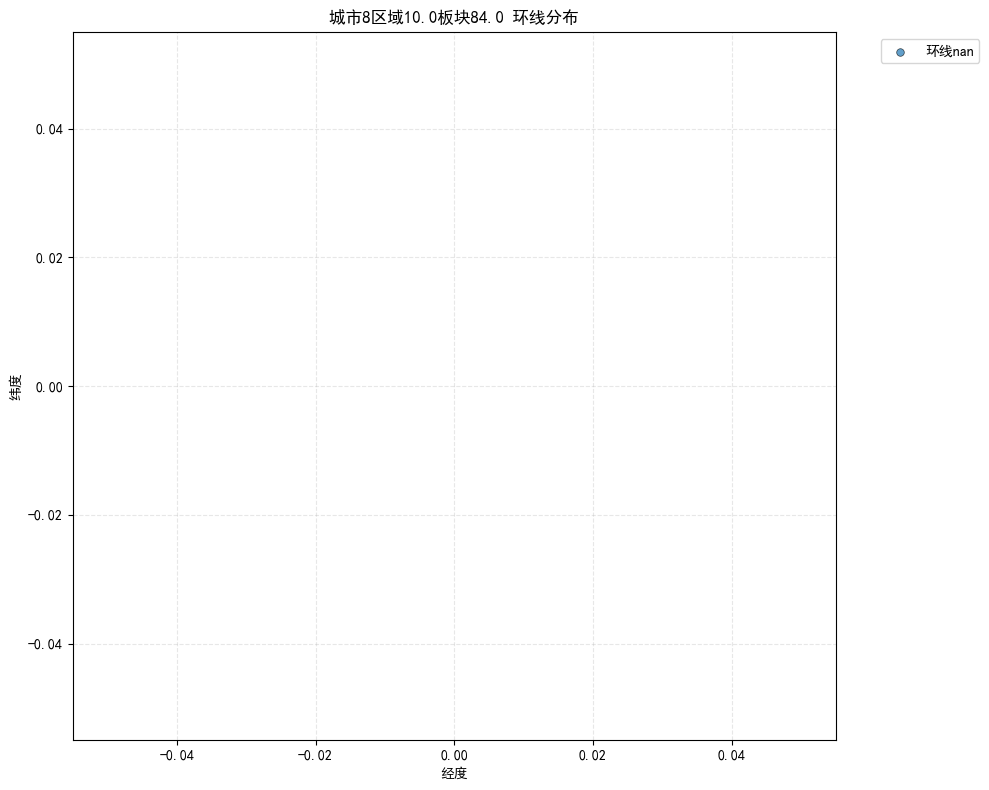


===== 处理城市 9 =====
样本总数：340
已知环线样本：0
需填充样本：340
警告：城市9无已知环线数据，无法填充
填充后有效样本数：0（完成率：0.00%）


C:\Users\杨\AppData\Local\Temp\ipykernel_25592\2000342585.py:142: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


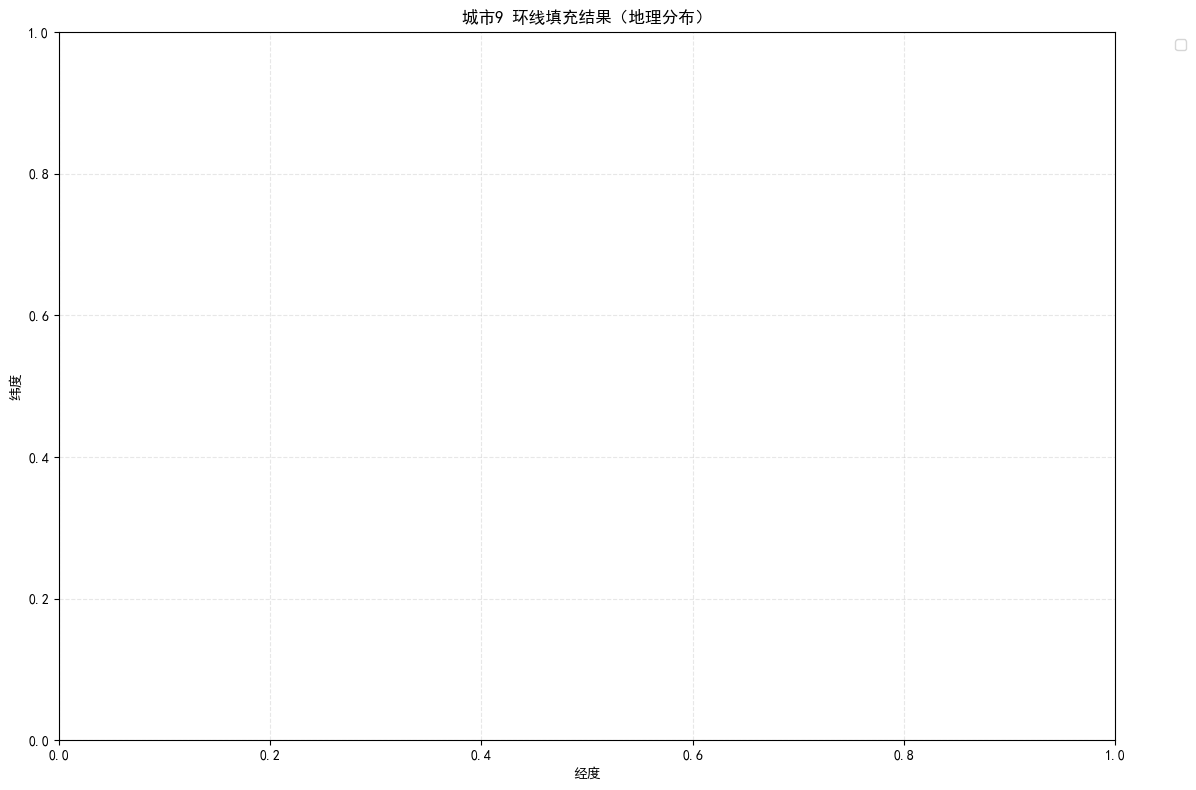


----- 处理城市9的区域 nan -----
区域样本数：0
区域环线分布：[]


C:\Users\杨\AppData\Local\Temp\ipykernel_25592\2000342585.py:159: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


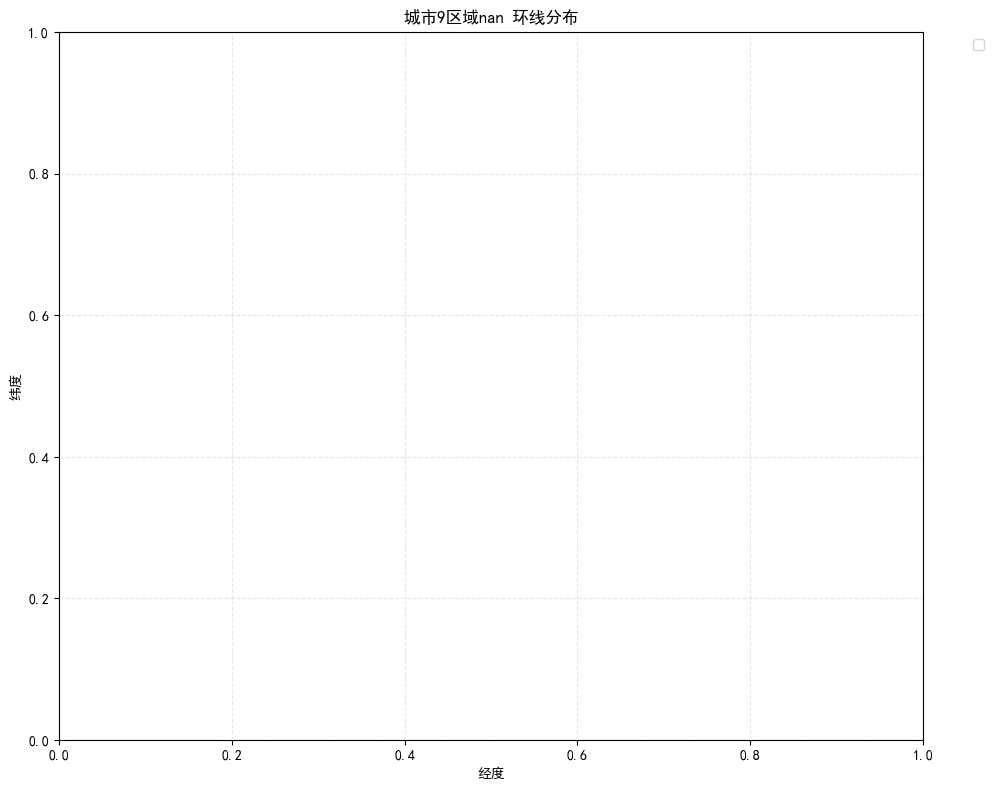


===== 处理城市 10 =====
样本总数：1070
已知环线样本：0
需填充样本：1070
警告：城市10无已知环线数据，无法填充
填充后有效样本数：0（完成率：0.00%）


C:\Users\杨\AppData\Local\Temp\ipykernel_25592\2000342585.py:142: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


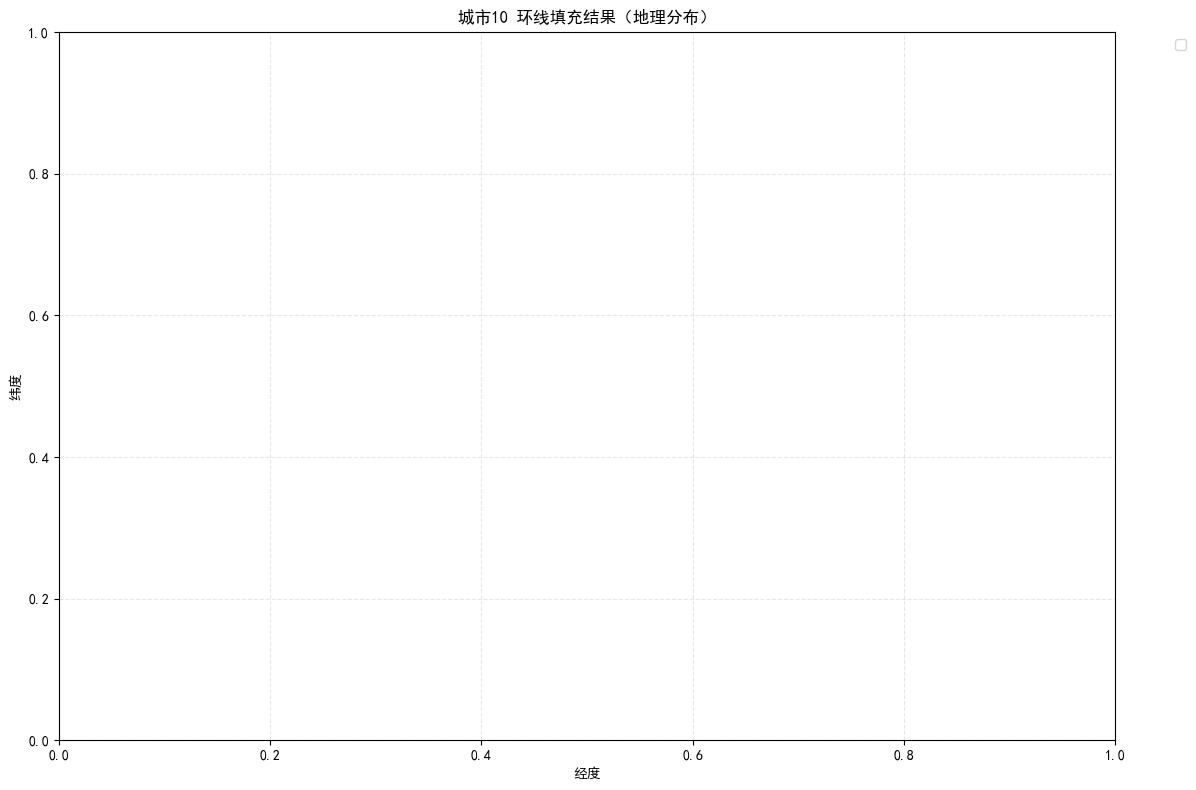


----- 处理城市10的区域 12.0 -----
区域样本数：13
区域环线分布：[np.float64(nan)]


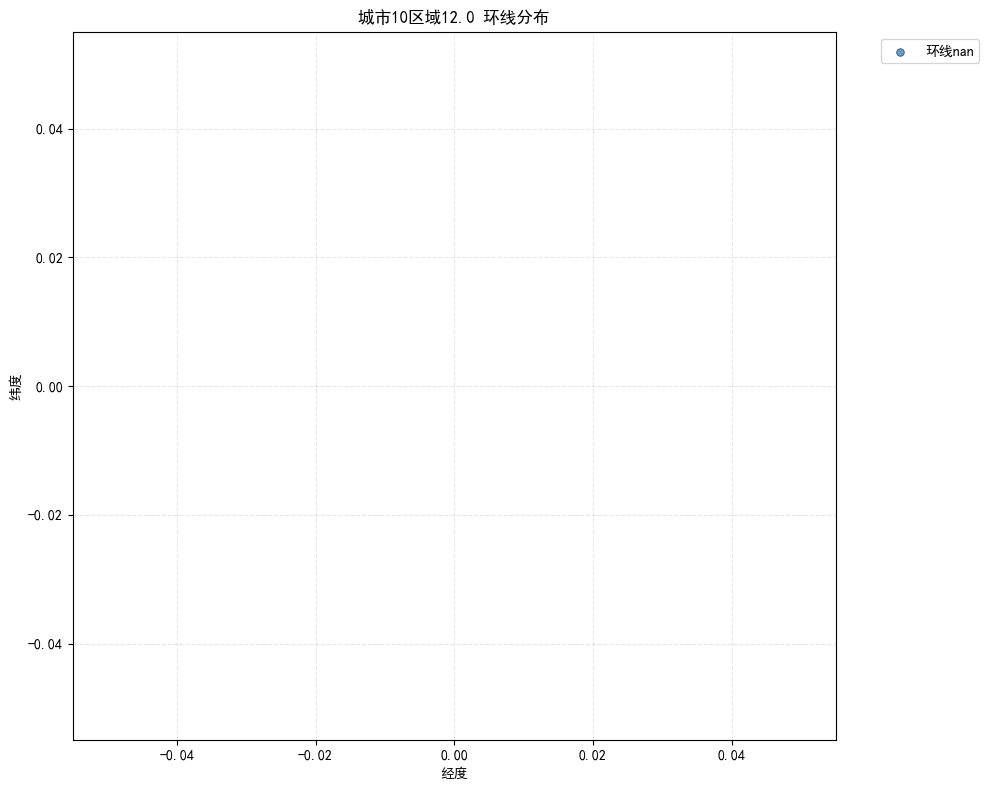

----- 处理区域12.0的板块 385.0 -----
板块样本数：9
板块环线分布：[np.float64(nan)]


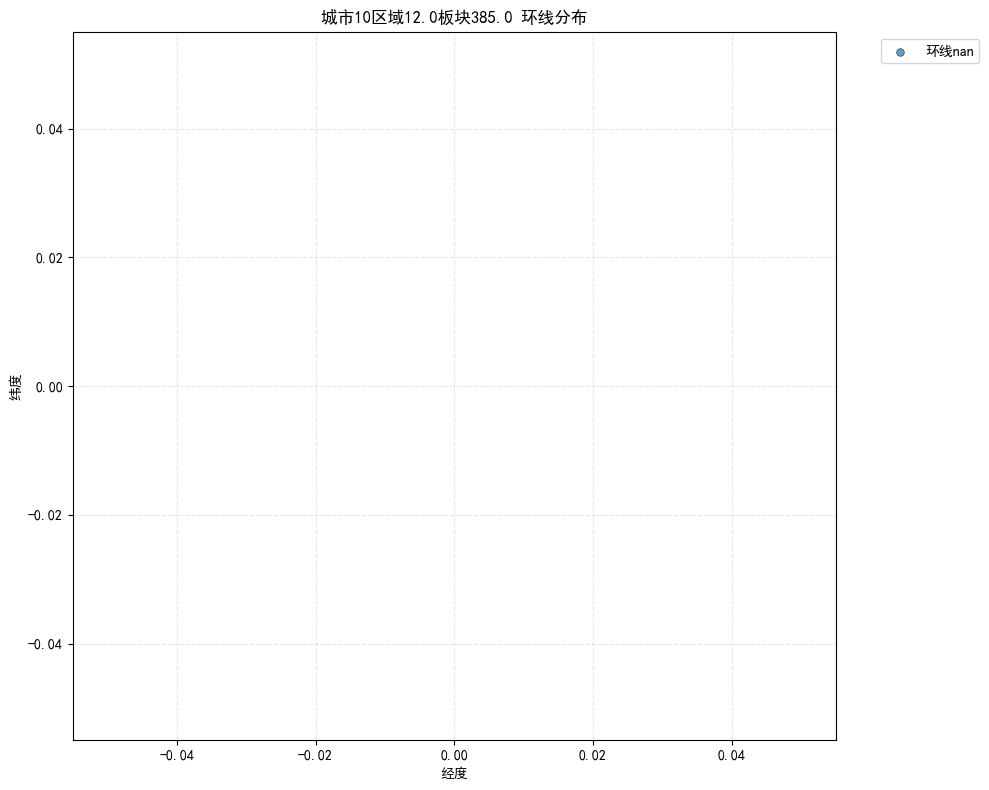


===== 处理城市 11 =====
样本总数：93
已知环线样本：0
需填充样本：93
警告：城市11无已知环线数据，无法填充
填充后有效样本数：0（完成率：0.00%）


C:\Users\杨\AppData\Local\Temp\ipykernel_25592\2000342585.py:142: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


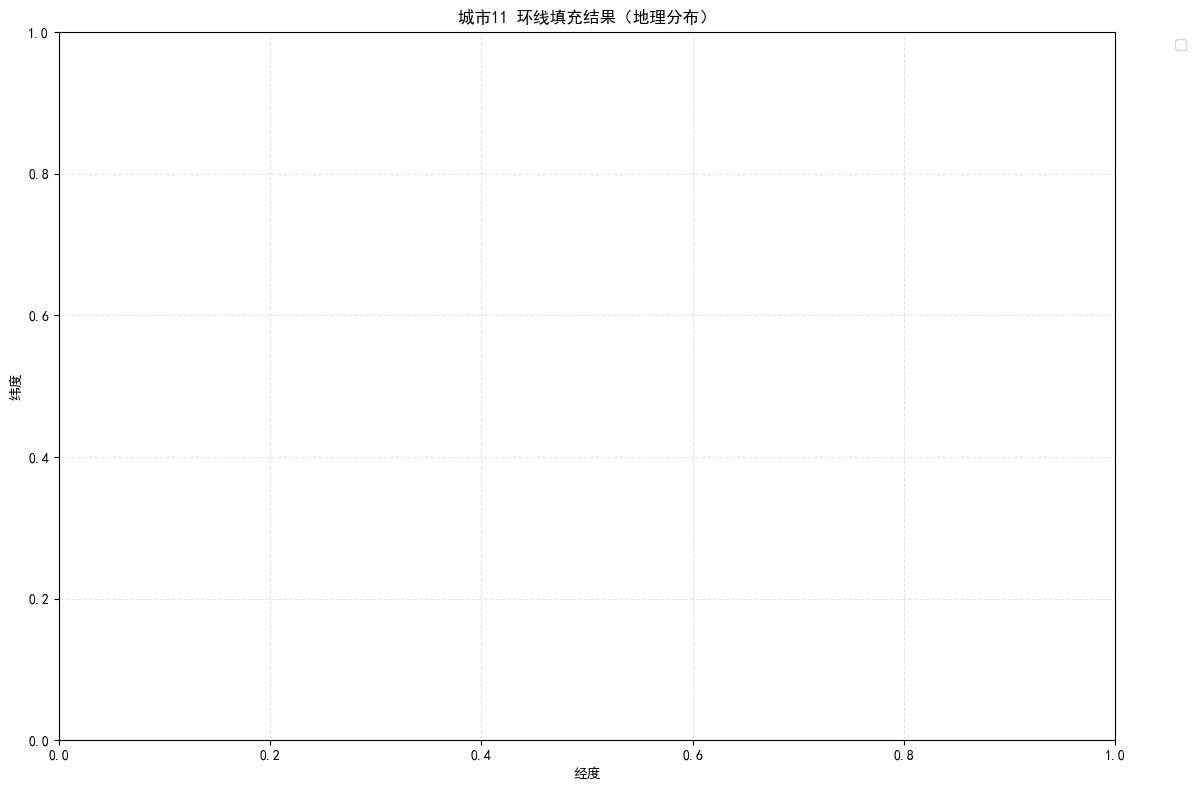


----- 处理城市11的区域 84.0 -----
区域样本数：32
区域环线分布：[np.float64(nan)]


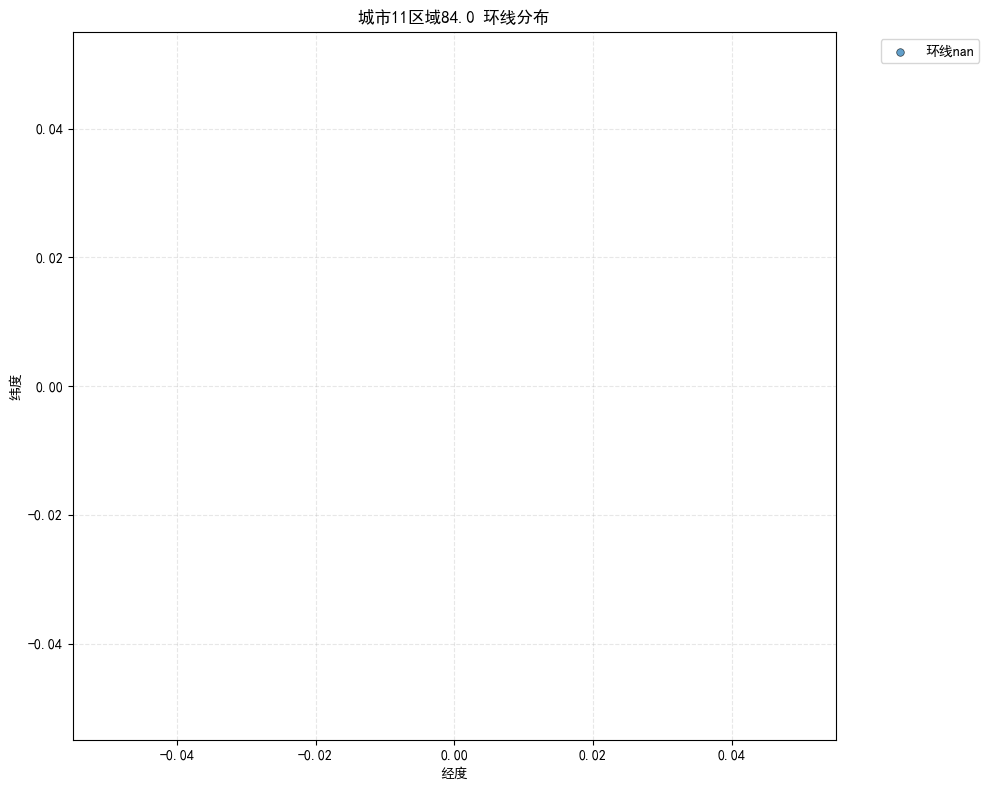

----- 处理区域84.0的板块 716.0 -----
板块样本数：32
板块环线分布：[np.float64(nan)]


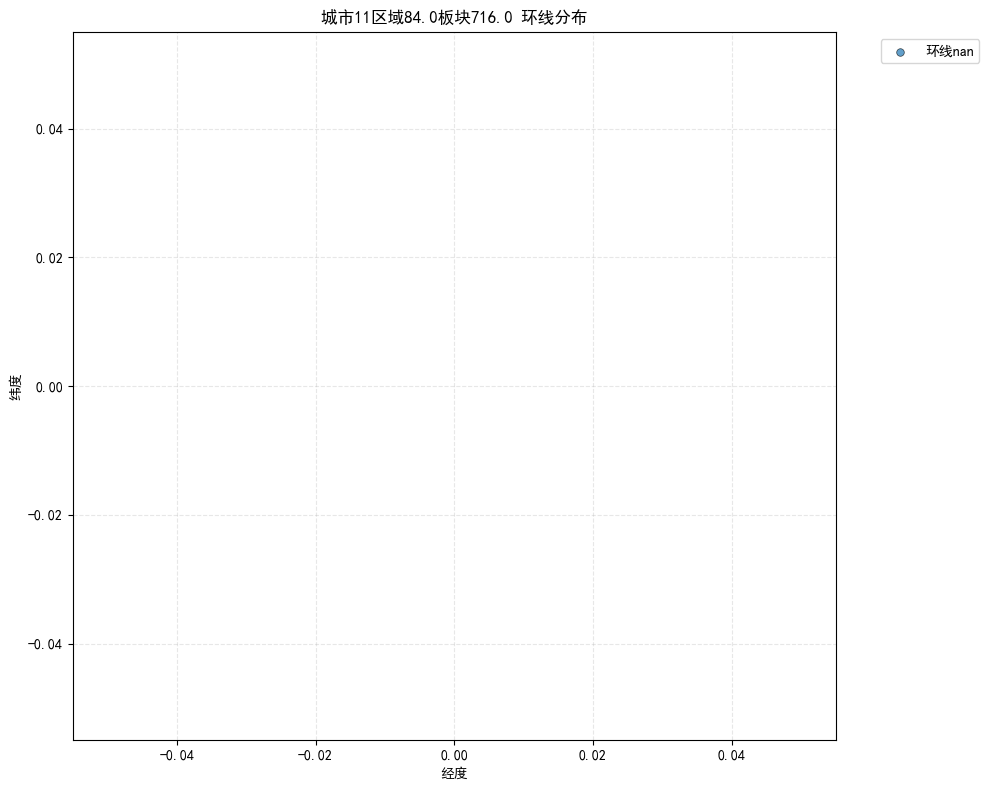


===== 所有城市处理完成：全局统计 =====
全局总样本数：9773
全局填充后有效样本数：4453
全局填充完成率：45.56%

各环线数值最终分布：
环线_数值
1.0       60
2.0     1586
3.0      267
4.0      286
5.0      608
6.0      217
7.0      347
8.0      553
9.0       76
10.0     129
11.0     324
Name: count, dtype: int64


In [18]:
#观察12个城市的房屋分布图，易得：城市1、5、6、8、9、10、11均为空缺值。其余部分有空缺值。我们先处理并不完全为空缺值的城市。
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from itertools import cycle

# 设置中文显示
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# ---------------------- 1. 数据准备 ----------------------
# 假设原始数据已加载到df中，包含['城市', '区域', '板块', 'lon', 'lat', '环线']等列
df = df.copy()  # 操作副本，避免修改原始数据

# 筛选有效经纬度数据，保留关键列
data = df[['城市', '区县', '板块', 'lon', 'lat', '环线位置']].dropna(subset=['lon', 'lat']).copy()

# 1.1 环线文字转数字映射
ring_mapping = {
    '二环内': 1, '二至三环': 3, '三至四环': 4, '四至五环': 6,
    '五至六环': 8, '六环外': 10, '内环内': 2, '内环至中环': 5,
    '中环至外环': 7, '内环至外环': 9, '外环外': 11
}
data['环线_数值'] = data['环线位置'].map(ring_mapping)  # 空缺值保留为NaN

# 查看数据基本信息
print("===== 数据基本信息 =====")
print(f"总样本数：{len(data)}")
print(f"环线数值非空样本数：{data['环线_数值'].notna().sum()}")
print(f"环线数值空缺样本数：{data['环线_数值'].isna().sum()}")
print(f"包含的城市列表：{sorted(data['城市'].unique())}\n")


# ---------------------- 2. 平面距离计算函数 ----------------------
def planar_distance(lat1, lon1, lat2, lon2):
    """计算平面坐标下的欧氏距离（适用于小范围地理数据）"""
    return np.hypot(lon2 - lon1, lat2 - lat1)


# ---------------------- 3. 环线空缺值填充核心函数 ----------------------
def cluster_fill_ring(city_group):
    """
    对单个城市的样本，基于已知环线数值和经纬度聚类填充空缺值
    """
    city = city_group['城市'].iloc[0]
    labeled = city_group[city_group['环线_数值'].notna()].copy()  # 已知样本
    unlabeled = city_group[city_group['环线_数值'].isna()].copy()  # 空缺样本
    filled_group = city_group.copy()

    # 若该城市无已知环线数据，返回原始数据
    if len(labeled) == 0:
        print(f"警告：城市{city}无已知环线数据，无法填充")
        return filled_group, None

    # 转换为相对坐标（基于城市整体经纬度最小值）
    min_lat, min_lon = city_group['lat'].min(), city_group['lon'].min()
    labeled['lat_rel'] = labeled['lat'] - min_lat
    labeled['lon_rel'] = labeled['lon'] - min_lon
    if len(unlabeled) > 0:
        unlabeled['lat_rel'] = unlabeled['lat'] - min_lat
        unlabeled['lon_rel'] = unlabeled['lon'] - min_lon

    # 已知样本聚类（簇数=已知环线类型数）
    n_clusters = len(labeled['环线_数值'].unique())
    labeled_features = labeled[['lat_rel', 'lon_rel']].values

    # 计算已知样本的距离矩阵并聚类
    condensed_dist = []
    for i in range(len(labeled_features)):
        for j in range(i + 1, len(labeled_features)):
            dist = planar_distance(
                labeled_features[i][0], labeled_features[i][1],
                labeled_features[j][0], labeled_features[j][1]
            )
            condensed_dist.append(dist)
    linkage_matrix = linkage(condensed_dist, method='average')
    labeled['cluster_label'] = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

    # 建立聚类标签与环线数值的映射（按众数）
    cluster_to_ring = labeled.groupby('cluster_label')['环线_数值'].agg(
        lambda x: x.mode()[0]
    ).to_dict()

    # 填充空缺样本
    if len(unlabeled) > 0:
        # 计算聚类中心
        cluster_centers = labeled.groupby('cluster_label')[['lat_rel', 'lon_rel']].mean()

        # 为空缺样本分配最近的聚类
        def assign_cluster(row):
            min_dist = np.inf
            best_cluster = 1
            for cluster, center in cluster_centers.iterrows():
                dist = planar_distance(row['lat_rel'], row['lon_rel'], center[0], center[1])
                if dist < min_dist:
                    min_dist = dist
                    best_cluster = cluster
            return best_cluster

        unlabeled['cluster_label'] = unlabeled.apply(assign_cluster, axis=1)
        unlabeled['环线_数值'] = unlabeled['cluster_label'].map(cluster_to_ring)
        filled_group.loc[unlabeled.index, '环线_数值'] = unlabeled['环线_数值']

    # 新增城市级聚类列（与环线数值一致）
    filled_group['城市级聚类'] = filled_group['环线_数值']
    return filled_group, linkage_matrix


# ---------------------- 4. 可视化函数 ----------------------
def plot_ring_cluster(data, city, linkage_matrix=None):
    """绘制单个城市的环线填充结果（区分已知/填充样本）"""
    # 聚类树（已知样本）
    if linkage_matrix is not None:
        plt.figure(figsize=(10, 6))
        dendrogram(linkage_matrix, truncate_mode='lastp', p=len(data['环线_数值'].unique()),
                   leaf_rotation=90, leaf_font_size=10)
        plt.xlabel('已知环线样本')
        plt.ylabel('相对距离（平面坐标）')
        plt.title(f'城市{city} 环线聚类树')
        plt.tight_layout()
        plt.show()

    # 地理散点图
    plt.figure(figsize=(12, 8))
    # 已知样本（彩色）
    known = data[data['环线位置'].notna()]
    for ring_val in known['环线_数值'].unique():
        subset = known[known['环线_数值'] == ring_val]
        plt.scatter(subset['lon'], subset['lat'], label=f'已知-环线{ring_val}',
                    s=40, alpha=0.8, edgecolors='k', linewidths=0.5)
    # 填充样本（灰色+红边）
    filled = data[data['环线位置'].isna() & data['环线_数值'].notna()]
    if len(filled) > 0:
        plt.scatter(filled['lon'], filled['lat'], c='gray', edgecolors='red',
                    label='填充-环线值', s=40, alpha=0.8, linewidths=0.5)

    plt.xlabel('经度')
    plt.ylabel('纬度')
    plt.title(f'城市{city} 环线填充结果（地理分布）')
    plt.grid(linestyle='--', alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def plot_region_plate_cluster(data, level, title_suffix):
    """绘制区域/板块级的环线分布"""
    plt.figure(figsize=(10, 8))
    colors = cycle(plt.cm.tab20(np.linspace(0, 1, len(data['环线_数值'].unique()))))
    for ring_val, color in zip(data['环线_数值'].unique(), colors):
        subset = data[data['环线_数值'] == ring_val]
        plt.scatter(subset['lon'], subset['lat'], c=[color], label=f'环线{ring_val}',
                    s=30, alpha=0.7, edgecolors='k', linewidths=0.5)
    plt.xlabel('经度')
    plt.ylabel('纬度')
    plt.title(f'{level} {title_suffix}')
    plt.grid(linestyle='--', alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# ---------------------- 5. 主流程：批量处理所有城市 ----------------------
# 获取所有不重复的城市
all_cities = sorted(data['城市'].unique())
print(f"开始批量处理所有城市，共{len(all_cities)}个城市...\n")

for target_city in all_cities:
    # 筛选当前城市数据
    city_data = data[data['城市'] == target_city].copy()
    print(f"\n===== 处理城市 {target_city} =====")
    print(f"样本总数：{len(city_data)}")
    print(f"已知环线样本：{len(city_data[city_data['环线_数值'].notna()])}")
    print(f"需填充样本：{len(city_data[city_data['环线_数值'].isna()])}")

    # 5.1 环线填充
    filled_city_data, ring_linkage = cluster_fill_ring(city_data)
    fill_count = filled_city_data['环线_数值'].notna().sum()
    fill_rate = (fill_count / len(filled_city_data)) * 100
    print(f"填充后有效样本数：{fill_count}（完成率：{fill_rate:.2f}%）")

    # 5.2 可视化城市级结果
    plot_ring_cluster(filled_city_data, target_city, ring_linkage)

    # 5.3 处理区域级（选最小编号区域作为示例）
    if not filled_city_data['区县'].empty:
        target_region = filled_city_data['区县'].min()
        region_data = filled_city_data[filled_city_data['区县'] == target_region].copy()
        print(f"\n----- 处理城市{target_city}的区域 {target_region} -----")
        print(f"区域样本数：{len(region_data)}")
        print(f"区域环线分布：{sorted(region_data['环线_数值'].unique())}")
        plot_region_plate_cluster(
            region_data,
            level=f'城市{target_city}区域{target_region}',
            title_suffix='环线分布'
        )

        # 5.4 处理板块级（选最小编号板块作为示例）
        if not region_data['板块'].empty:
            target_plate = region_data['板块'].min()
            plate_data = region_data[region_data['板块'] == target_plate].copy()
            print(f"----- 处理区域{target_region}的板块 {target_plate} -----")
            print(f"板块样本数：{len(plate_data)}")
            print(f"板块环线分布：{sorted(plate_data['环线_数值'].unique())}")
            plot_region_plate_cluster(
                plate_data,
                level=f'城市{target_city}区域{target_region}板块{target_plate}',
                title_suffix='环线分布'
            )

    # 将填充结果合并回原始df
    df.loc[filled_city_data.index, '环线_数值'] = filled_city_data['环线_数值']


# ---------------------- 6. 全局结果统计 ----------------------
print("\n===== 所有城市处理完成：全局统计 =====")
total_samples = len(data)
filled_total = df.loc[data.index, '环线_数值'].notna().sum()
global_rate = (filled_total / total_samples) * 100
print(f"全局总样本数：{total_samples}")
print(f"全局填充后有效样本数：{filled_total}")
print(f"全局填充完成率：{global_rate:.2f}%")
print("\n各环线数值最终分布：")
print(df['环线_数值'].value_counts().sort_index())

# 保存处理后的完整数据（可选）
# df.to_csv('处理后数据.csv', index=False)
# print("处理后的数据已保存为'处理后数据.csv'")

In [19]:
#观察12个城市的房屋分布图，易得：城市1、3,5、6、8、9、10、11均为空缺值。可以推测得出，这些城市大概率不区分环线。我们决定使用0来填充这些城市的空缺值。
import pandas as pd

# 确保操作副本，避免修改原始数据
df = df.copy()

# 1. 定义需填充0的城市列表
target_cities = [1,3, 5, 6, 8, 9, 10, 11]

# 2. 筛选指定城市，将其“环线”列填充为0
# 用isin()匹配目标城市，loc定位并赋值
df.loc[df['城市'].isin(target_cities), '环线_数值'] = 0

# 3. 验证填充结果（确认是否全部填充成功）
print("指定城市的'环线_数值'列填充结果验证：")
for city in target_cities:
    # 筛选当前城市数据
    city_data = df[df['城市'] == city]
    # 计算环线值为0的比例
    zero_ratio = (city_data['环线_数值'] == 0).mean()
    # 统计当前城市数据量
    data_count = len(city_data)
    print(f"城市{city}：共{data_count}条数据，环线_数值为0的比例：{zero_ratio:.2%}")

指定城市的'环线_数值'列填充结果验证：
城市1：共567条数据，环线_数值为0的比例：100.00%
城市3：共1802条数据，环线_数值为0的比例：100.00%
城市5：共592条数据，环线_数值为0的比例：100.00%
城市6：共188条数据，环线_数值为0的比例：100.00%
城市8：共668条数据，环线_数值为0的比例：100.00%
城市9：共340条数据，环线_数值为0的比例：100.00%
城市10：共1070条数据，环线_数值为0的比例：100.00%
城市11：共93条数据，环线_数值为0的比例：100.00%


In [20]:
df_rent_train=df

In [21]:
import pandas as pd
import re

def quantize_gas_fee(gas_fee_str):
    # 1. 处理空缺值
    if pd.isna(gas_fee_str) or str(gas_fee_str).strip() == '':
        return 0.0
    
    # 2. 提取所有数字（支持整数、小数）
    numbers = re.findall(r'(\d+\.?\d*)', str(gas_fee_str))
    if not numbers:  # 无有效数字（异常值）
        return 0.0
    
    # 3. 转换为浮点数
    numbers = [float(num) for num in numbers]
    
    # 4. 处理固定单价（仅1个数字）
    if len(numbers) == 1:
        return round(numbers[0], 2)  # 保留2位小数，符合金额格式
    
    # 5. 处理单价区间（2个数字）
    elif len(numbers) == 2:
        min_val = min(numbers)
        max_val = max(numbers)
        # 极端区间（跨度＞3）：用民用燃气价中位数2.5替代
        if (max_val - min_val) > 3:
            return 2.5
        # 正常区间：取中间值
        mid_val = (min_val + max_val) / 2
        return round(mid_val, 2)
    
    # 6. 超过2个数字（异常格式）：取平均值
    else:
        avg_val = sum(numbers) / len(numbers)
        return round(avg_val, 2)

# 生成量化列
df_rent_train['燃气费_量化'] = df_rent_train['燃气费'].apply(quantize_gas_fee)

# 查看量化结果
print("燃气费_量化分布（单位：元/m³）：")
print(df_rent_train['燃气费_量化'].value_counts().sort_index().head(10))  # 显示前10个常见值
print(f"\n空缺值/异常值（量化为0）的数量：{sum(df_rent_train['燃气费_量化'] == 0)}")

# 查看前10条数据的原始值与量化值
print("\n前10条数据示例：")
print(df_rent_train[['燃气费', '燃气费_量化']].head(10))

燃气费_量化分布（单位：元/m³）：
燃气费_量化
0.00    3142
0.40       1
1.00       5
1.51       1
1.62       3
1.70       3
1.72       3
1.73      10
1.84       9
1.85       9
Name: count, dtype: int64

空缺值/异常值（量化为0）的数量：3142

前10条数据示例：
        燃气费  燃气费_量化
0  2.15元/m³    2.15
1  3.45元/m³    3.45
2       NaN    0.00
3  2.61元/m³    2.61
4       NaN    0.00
5  1.98元/m³    1.98
6       NaN    0.00
7     3元/m³    3.00
8       NaN    0.00
9  2.46元/m³    2.46


In [22]:
import pandas as pd
import re

def quantize_heating_fee(heating_fee_str):
    # 1. 处理空缺值
    if pd.isna(heating_fee_str) or str(heating_fee_str).strip() == '':
        return 0.0
    
    # 2. 提取所有数字（支持整数、小数）
    numbers = re.findall(r'(\d+\.?\d*)', str(heating_fee_str))
    if not numbers:  # 无有效数字（异常值）
        return 0.0
    
    # 3. 转换为浮点数
    numbers = [float(num) for num in numbers]
    
    # 4. 处理固定单价（仅1个数字）
    if len(numbers) == 1:
        return round(numbers[0], 2)  # 保留2位小数
    
    # 5. 处理单价区间（2个数字）
    elif len(numbers) == 2:
        min_val = min(numbers)
        max_val = max(numbers)
        span = max_val - min_val
        # 极端区间（跨度＞20）：按民用/商用常见价修正
        if span > 20:
            # 若区间包含民用价（如0.5-29.55含25左右），取25；含高价（如30-50）取40
            if max_val <= 30:
                return 25.0  # 偏民用
            else:
                return 40.0  # 偏商用
        # 正常区间：取中间值
        mid_val = (min_val + max_val) / 2
        return round(mid_val, 2)
    
    # 6. 超过2个数字（异常格式）：取平均值
    else:
        avg_val = sum(numbers) / len(numbers)
        return round(avg_val, 2)

# 生成量化列
df_rent_train['供热费_量化'] = df_rent_train['供热费'].apply(quantize_heating_fee)

# 查看量化结果
print("供热费_量化分布（单位：元/㎡）：")
print(df_rent_train['供热费_量化'].value_counts().sort_index().head(10))  # 显示前10个常见值
print(f"\n空缺值/异常值（量化为0）的数量：{sum(df_rent_train['供热费_量化'] == 0)}")

# 查看前10条数据的原始值与量化值
print("\n前10条数据示例：")
print(df_rent_train[['供热费', '供热费_量化']].head(10))

供热费_量化分布（单位：元/㎡）：
供热费_量化
0.00    7054
0.01       5
0.10       5
0.50      10
0.52      43
0.55       1
0.75      17
1.00     340
1.10       3
1.20       2
Name: count, dtype: int64

空缺值/异常值（量化为0）的数量：7054

前10条数据示例：
     供热费  供热费_量化
0    NaN     0.0
1    NaN     0.0
2    NaN     0.0
3  30元/㎡    30.0
4    NaN     0.0
5    NaN     0.0
6    NaN     0.0
7    NaN     0.0
8    NaN     0.0
9  21元/㎡    21.0


In [23]:
import pandas as pd

def quantize_parking_space(parking_num):
    # 1. 处理空缺值
    if pd.isna(parking_num) or str(parking_num).strip() == '':
        return 0
    # 2. 处理非数字格式（异常值）
    try:
        num = int(parking_num)
    except:
        return 0
    # 3. 按数量分箱量化
    if num <= 1:
        return 1
    elif 2 <= num <= 10:
        return 2
    elif 11 <= num <= 100:
        return 3
    elif 101 <= num <= 500:
        return 4
    else:  # ＞500个（极端值）
        return 5

# 生成量化列
df_rent_train['停车位_量化'] = df_rent_train['停车位'].apply(quantize_parking_space)

# 查看量化结果
print("停车位_量化分布（数值=等级，0=未知）：")
print(df_rent_train['停车位_量化'].value_counts().sort_index())
print(f"\n空缺值/异常值（量化为0）的数量：{sum(df_rent_train['停车位_量化'] == 0)}")

# 查看前10条数据的原始值与量化值
print("\n前10条数据示例：")
print(df_rent_train[['停车位', '停车位_量化']].head(10))

停车位_量化分布（数值=等级，0=未知）：
停车位_量化
0    3115
1      24
2      35
3     585
4    2108
5    3906
Name: count, dtype: int64

空缺值/异常值（量化为0）的数量：3115

前10条数据示例：
      停车位  停车位_量化
0  1600.0       5
1   200.0       4
2     NaN       0
3  2317.0       5
4     NaN       0
5  1699.0       5
6     NaN       0
7   200.0       4
8     NaN       0
9   500.0       4


In [24]:
import pandas as pd
import re

def quantize_parking_fee(fee_str):
    # 1. 处理空缺值或未知值
    if pd.isna(fee_str):
        return -1
    fee_str = str(fee_str).strip().lower()
    if fee_str in ['', '未知', '无', '暂无']:
        return -1
    
    # 统一格式：替换特殊符号，便于正则匹配
    fee_str = fee_str.replace('～', '-').replace('；', ',').replace('，', ',').replace('／', '/')
    
    # 2. 优先提取“月租”相关数值（核心目标）
    # 修正正则：用非捕获组统一模式，避免返回元组
    month_pattern = r'\b(\d+\.?\d*)\s*(元/月|月/位|元每月|元\/月)\b'
    month_matches = re.findall(month_pattern, fee_str)
    # 提取数字部分（忽略单位）
    month_values = [float(match[0]) for match in month_matches if match[0].strip()]
    if month_values:
        return round(month_values[0], 0)  # 取第一个有效月租
    
    # 3. 处理地上/地下区分（优先地上）
    if '地上' in fee_str:
        ground_pattern = r'地上\D*(\d+\.?\d*)\D*'
        ground_matches = re.findall(ground_pattern, fee_str)
        if ground_matches and ground_matches[0].strip():
            return round(float(ground_matches[0]), 0)
    
    # 无地上则取地下
    if '地下' in fee_str:
        underground_pattern = r'地下\D*(\d+\.?\d*)\D*'
        underground_matches = re.findall(underground_pattern, fee_str)
        if underground_matches and underground_matches[0].strip():
            return round(float(underground_matches[0]), 0)
    
    # 4. 处理费用区间（如300-400元/月）
    range_pattern = r'(\d+\.?\d*)-(\d+\.?\d*)\s*元'
    range_matches = re.findall(range_pattern, fee_str)
    if range_matches:
        min_val = float(range_matches[0][0])
        max_val = float(range_matches[0][1])
        return round((min_val + max_val) / 2, 0)
    
    # 5. 处理免费情况
    if '免费' in fee_str or '0元' in fee_str:
        return 0
    
    # 6. 时租转月租（按每月240小时估算：30天×8小时/天）
    hour_pattern = r'\b(\d+\.?\d*)\s*(元/小时|元\/时)\b'
    hour_matches = re.findall(hour_pattern, fee_str)
    hour_values = [float(match[0]) for match in hour_matches if match[0].strip()]
    if hour_values:
        return round(hour_values[0] * 240, 0)
    
    # 7. 年租转月租
    year_pattern = r'\b(\d+\.?\d*)\s*(元/年|元\/年)\b'
    year_matches = re.findall(year_pattern, fee_str)
    year_values = [float(match[0]) for match in year_matches if match[0].strip()]
    if year_values:
        return round(year_values[0] / 12, 0)
    
    # 8. 仅数字（无单位，默认按月租处理，过滤异常大值）
    num_pattern = r'^\d+\.?\d*$'
    if re.match(num_pattern, fee_str):
        num = float(fee_str)
        return round(num, 0) if num <= 2000 else -1  # 月租超过2000视为异常
    
    # 9. 其他无法识别的情况
    return -1

# 应用量化函数到数据框
df_rent_train['停车费用_量化'] = df_rent_train['停车费用'].apply(quantize_parking_fee)

# 查看结果
print("量化结果统计：")
print(f"未知值（-1）数量：{sum(df_rent_train['停车费用_量化'] == -1)}")
print(f"免费（0）数量：{sum(df_rent_train['停车费用_量化'] == 0)}")
print("\n前10条数据示例：")
print(df_rent_train[['停车费用', '停车费用_量化']].head(10))

量化结果统计：
未知值（-1）数量：3597
免费（0）数量：43

前10条数据示例：
   停车费用  停车费用_量化
0   100    100.0
1   800    800.0
2   NaN     -1.0
3  1200   1200.0
4   NaN     -1.0
5   450    450.0
6   NaN     -1.0
7   150    150.0
8   NaN     -1.0
9   180    180.0


In [25]:
# 定义需要保留的列名列表
selected_columns = [
    '城市', '装修', '年份', '户型完整度评分', '楼层完整度评分',
    '面积_数值', '朝向评分', '付款方式_量化', '租赁方式_量化', '电梯_量化',
    '车位_量化', '用水_量化', '用电_量化', '燃气_量化', '采暖_量化', '租期_量化',
    '配套设施_量化', '环线_数值', '燃气费_量化', '停车位_量化', '停车费用_量化'
]

# 选取指定列，生成新的数据框
df_selected = df_rent_train[selected_columns].copy()

# 查看选取结果（前5行）
print("选取的列及前5行数据：")
print(df_selected.head())

# 确认列数是否正确
print(f"\n选取的列数：{df_selected.shape[1]}（预期22列）")

选取的列及前5行数据：
   城市  装修    年份  户型完整度评分  楼层完整度评分   面积_数值  朝向评分  付款方式_量化  租赁方式_量化  电梯_量化  ...  \
0   1   1  2023       10        0   86.94     4        0        2      2  ...   
1  10   1  2022       10        0   72.60     4        1        2      2  ...   
2   3   1  2022       10        0   98.00     4        0        2      2  ...   
3   0   1  2022       10        0   98.97     2        3        2      2  ...   
4   3   1  2022       10        0  170.53     4        3        2      2  ...   

   用水_量化  用电_量化  燃气_量化  采暖_量化  租期_量化  配套设施_量化  环线_数值  燃气费_量化  停车位_量化  停车费用_量化  
0      1      1      2      1      0        9    0.0    2.15       5    100.0  
1      1      1      2      0      0        6    0.0    3.45       4    800.0  
2      0      0      2      0      6        8    0.0    0.00       0     -1.0  
3      1      1      2      2      0        0    4.0    2.61       5   1200.0  
4      1      1      2      0      0        8    0.0    0.00       0     -1.0  

[5 rows x 21 columns

In [28]:
# 检查各列空缺值数量及占比
missing_stats = pd.DataFrame({
    '空缺值数量': df_selected.isnull().sum(),
    '空缺值占比': df_selected.isnull().mean().round(4) * 100  # 保留4位小数并转为百分比
})

# 按空缺值数量从多到少排序，仅显示存在空缺值的列
missing_stats = missing_stats[missing_stats['空缺值数量'] > 0].sort_values(by='空缺值数量', ascending=False)

# 输出结果
print("各列空缺值统计（仅显示存在空缺值的列）：")
print(missing_stats)

# 总体缺失情况
total_rows = df_selected.shape[0]
rows_without_missing = df_selected.dropna().shape[0]
print(f"\n总记录数：{total_rows}")
print(f"无任何空缺值的记录数：{rows_without_missing}")
print(f"完全无缺失的记录占比：{round(rows_without_missing / total_rows * 100, 2)}%")

各列空缺值统计（仅显示存在空缺值的列）：
Empty DataFrame
Columns: [空缺值数量, 空缺值占比]
Index: []

总记录数：9773
无任何空缺值的记录数：9773
完全无缺失的记录占比：100.0%


In [29]:
# 定义特征列（X）和目标列（Y）
# 特征列包含指定的23个列（注意：包含Price是你要求的，若实际分析中需排除可移除）
feature_columns = [
    '城市', '装修', '年份', '户型完整度评分', '楼层完整度评分',
    '面积_数值', '朝向评分', '付款方式_量化', '租赁方式_量化', '电梯_量化',
    '车位_量化', '用水_量化', '用电_量化', '燃气_量化', '采暖_量化', '租期_量化',
    '配套设施_量化', '环线_数值', '燃气费_量化', '停车位_量化', '停车费用_量化'
]

# 提取特征列（确保只包含数据中存在的列）
existing_features = [col for col in feature_columns if col in df.columns]
X = df[existing_features].copy()



# 验证结果
print("=" * 60)
print(f"X的形状（样本数, 特征数）：{X.shape}")
print(f"X包含的列：{X.columns.tolist()}")
print("\n" + "=" * 60)

X的形状（样本数, 特征数）：(9773, 21)
X包含的列：['城市', '装修', '年份', '户型完整度评分', '楼层完整度评分', '面积_数值', '朝向评分', '付款方式_量化', '租赁方式_量化', '电梯_量化', '车位_量化', '用水_量化', '用电_量化', '燃气_量化', '采暖_量化', '租期_量化', '配套设施_量化', '环线_数值', '燃气费_量化', '停车位_量化', '停车费用_量化']



In [34]:
# 定义推荐的特征列表
recommended_features = [
    '面积_数值', 
    '停车费用_量化', 
    '采暖_量化', 
    '环线_数值', 
    '停车位_量化', 
    '配套设施_量化', 
    '付款方式_量化', 
    '用水_量化', 
    '租期_量化', 
    '城市'
]

# 检查特征是否都存在于df中
missing_features = [f for f in recommended_features if f not in df.columns]
if missing_features:
    raise ValueError(f"以下特征在df中不存在，请检查列名：{missing_features}")

# 提取特征并存储到X中
X = df[recommended_features].copy()

# 查看X的基本信息（确认提取结果）
print("特征数据X的基本信息：")
print(f"形状：{X.shape}（行：样本数，列：特征数）")
print("\n前5行数据：")
print(X.head())

X_new=X

特征数据X的基本信息：
形状：(9773, 10)（行：样本数，列：特征数）

前5行数据：
    面积_数值  停车费用_量化  采暖_量化  环线_数值  停车位_量化  配套设施_量化  付款方式_量化  用水_量化  租期_量化  城市
0   86.94    100.0      1    0.0       5        9        0      1      0   1
1   72.60    800.0      0    0.0       4        6        1      1      0  10
2   98.00     -1.0      0    0.0       0        8        0      0      6   3
3   98.97   1200.0      2    4.0       5        0        3      1      0   0
4  170.53     -1.0      0    0.0       0        8        3      1      0   3


In [35]:
# ----------------------
# 新增：将X_new保存为CSV文件
# ----------------------
if 'X_new' in locals() or 'X_new' in globals():
    # 保存X_new，支持中文，不保留索引（若需要保留索引可设为index=True）
    X_new.to_csv("X_new_rent.csv", index=False, encoding="utf-8-sig")
    print("\nX_new已保存为CSV文件：X_new_rent.csv")
else:
    print("\n未找到X_new数据，无法保存。")


X_new已保存为CSV文件：X_new_rent.csv
